# 📊 Notebook 0 — Inventário e Estatísticas dos Datasets

Baixa **metadados** (summaries, TSVs, JSONs, TXTs, XLSX) de **todos** os pacientes,
constrói **4 tabelas detalhadas** e uma **tabela comparativa final** com estatísticas.

| Dataset | Pacientes | Método de download |
|---------|-----------|-------------------|
| CHB-MIT | 23 | S3 anônimo (`physionet-open`) — sem conta |
| Siena | 14 | HTTPS público (`physionet.org`) — sem conta |
| Mendeley | 6 | API pública + cloudscraper |
| SeizeIT2 | 125 | S3 anônimo (`openneuro.org`) — sem conta |

> **Seção 9 (opcional, comentada):** baixa os EDFs com crise para uso no NB1.


## 0. Imports e configuração

In [4]:
%pip install -q numpy pandas matplotlib boto3 tqdm cloudscraper openpyxl requests

import os, re, json, io, warnings, html.parser, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import boto3
from botocore import UNSIGNED
from botocore.config import Config
from tqdm.auto import tqdm
import cloudscraper
import IPython.display as ipd

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Diretórios ───────────────────────────────────────────────────────────────
ROOT_DIR     = 'data'
CHBMIT_DIR   = os.path.join(ROOT_DIR, 'chb-mit')
SIENA_DIR    = os.path.join(ROOT_DIR, 'siena')
SEIZEIT_DIR  = os.path.join(ROOT_DIR, 'seizeit2')
MENDELEY_DIR = os.path.join(ROOT_DIR, 'mendeley')
OUT_DIR      = os.path.join(ROOT_DIR, 'inventory')
for d in [CHBMIT_DIR, SIENA_DIR, SEIZEIT_DIR, MENDELEY_DIR, OUT_DIR,
          os.path.join(MENDELEY_DIR, 'Documentation'),
          os.path.join(MENDELEY_DIR, 'Raw_EDF_Files')]:
    os.makedirs(d, exist_ok=True)

# ── Todos os pacientes ───────────────────────────────────────────────────────
PATIENTS = {
    'CHBMIT'  : [f'chb{i:02d}' for i in range(1, 24)],       # chb01..chb23
    'Siena'   : ['PN00','PN01','PN03','PN05','PN06',
                 'PN07','PN09','PN10','PN11','PN12',
                 'PN13','PN14','PN16','PN17'],                  # 14 pacientes
    'Mendeley': [f'p{i}' for i in range(10, 16)],              # p10..p15
    'SeizeIT2': [f'sub-{i:03d}' for i in range(1, 126)],      # sub-001..sub-125
}
SEIZEIT_SESSION = 'ses-01'

# ── Constantes dos datasets (mesmas do NB1) ───────────────────────────────────
CHBMIT_BUCKET  = 'physionet-open'
CHBMIT_PREFIX  = 'chbmit/1.0.0/'
SIENA_BASE     = 'https://physionet.org/files/siena-scalp-eeg/1.0.0/'
SEIZEIT_BUCKET  = 'openneuro.org'
SEIZEIT_DATASET = 'ds005873'
MEND_DATASET_ID = '5pc2j46cbc'
MEND_VERSION    = 1
MEND_DOC_FOLDER = '465c0896-7d08-4fbe-8ee3-378beca656d5'
MEND_EDF_FOLDER = '3bc6cc31-0156-490b-8e39-4b740598b289'
_MEND_HEADERS   = {'Accept': 'application/vnd.mendeley-public-dataset.1+json'}

# ── Helpers de tempo ─────────────────────────────────────────────────────────
def sec_to_min(s):  return round(s / 60,   2) if s is not None else None
def sec_to_h(s):    return round(s / 3600, 4) if s is not None else None

def hms_to_sec(s):
    s = str(s).strip().replace(':', '.')
    p = s.split('.')
    if len(p) == 3: return int(p[0])*3600 + int(p[1])*60 + int(p[2])
    return 0

def clock_offset(reg_start_s, event_s):
    diff = event_s - reg_start_s
    return diff + 86400 if diff < 0 else diff

def duration_str_to_sec(txt):
    txt = str(txt)
    mm = re.search(r'(\d+)\s*min', txt); ss = re.search(r'(\d+)\s*sec', txt)
    total = (int(mm.group(1))*60 if mm else 0) + (int(ss.group(1)) if ss else 0)
    return total if total > 0 else None

# ── S3 anônimo (mesmo método do NB1) ─────────────────────────────────────────
def s3_client():
    return boto3.client('s3', region_name='us-east-1',
                        config=Config(signature_version=UNSIGNED))

# ── LinkParser HTML (mesmo do NB1) ────────────────────────────────────────────
class _LinkParser(html.parser.HTMLParser):
    def __init__(self): super().__init__(); self.links = []
    def handle_starttag(self, tag, attrs):
        if tag == 'a':
            for attr, val in attrs:
                if attr == 'href' and not val.startswith(('?','/','..')):
                    self.links.append(val)

print('✅ Configurações OK')
print(f'   CHB-MIT : {len(PATIENTS["CHBMIT"])} pacientes  (S3 anônimo — sem conta)')
print(f'   Siena   : {len(PATIENTS["Siena"])} pacientes  (HTTPS público — sem conta)')
print(f'   Mendeley: {len(PATIENTS["Mendeley"])} pacientes   (API pública + cloudscraper)')
print(f'   SeizeIT2: {len(PATIENTS["SeizeIT2"])} pacientes (S3 anônimo — sem conta)')


Note: you may need to restart the kernel to use updated packages.
✅ Configurações OK
   CHB-MIT : 23 pacientes  (S3 anônimo — sem conta)
   Siena   : 14 pacientes  (HTTPS público — sem conta)
   Mendeley: 6 pacientes   (API pública + cloudscraper)
   SeizeIT2: 125 pacientes (S3 anônimo — sem conta)



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## 1. Download de metadados — CHB-MIT

Usa S3 anônimo (`physionet-open`), exatamente como o NB1. Sem conta PhysioNet necessária.

In [5]:
def download_chbmit_metadata(patients=PATIENTS['CHBMIT'], local_root=CHBMIT_DIR):
    """
    Baixa SUBJECT-INFO, RECORDS-WITH-SEIZURES e <patient>-summary.txt
    via S3 anônimo (physionet-open) — sem autenticação.
    """
    s3 = s3_client()
    downloaded = 0

    # SUBJECT-INFO
    local_si = os.path.join(local_root, 'SUBJECT-INFO')
    if not os.path.exists(local_si):
        print('⬇️  SUBJECT-INFO ...')
        s3.download_file(CHBMIT_BUCKET, CHBMIT_PREFIX + 'SUBJECT-INFO', local_si)
        downloaded += 1

    # RECORDS-WITH-SEIZURES (usado também pelo NB1)
    local_rws = os.path.join(local_root, 'RECORDS-WITH-SEIZURES')
    if not os.path.exists(local_rws):
        print('⬇️  RECORDS-WITH-SEIZURES ...')
        s3.download_file(CHBMIT_BUCKET, CHBMIT_PREFIX + 'RECORDS-WITH-SEIZURES', local_rws)
        downloaded += 1

    # summary.txt de cada paciente
    for pat in tqdm(patients, desc='CHB-MIT summaries'):
        pat_dir = os.path.join(local_root, pat)
        os.makedirs(pat_dir, exist_ok=True)
        fname   = f'{pat}-summary.txt'
        local   = os.path.join(pat_dir, fname)
        if not os.path.exists(local):
            try:
                s3.download_file(CHBMIT_BUCKET, f'{CHBMIT_PREFIX}{pat}/{fname}', local)
                downloaded += 1
            except Exception as e:
                print(f'  ⚠️  {pat}: {e}')

    print(f'✅ CHB-MIT metadados — {downloaded} arquivos novos baixados')

download_chbmit_metadata()


CHB-MIT summaries: 100%|██████████| 23/23 [00:00<00:00, 1470.74it/s]

✅ CHB-MIT metadados — 0 arquivos novos baixados


---
## 2. Download de metadados — Siena

Usa HTTPS público sem autenticação, exatamente como o NB1.

In [6]:
def download_siena_metadata(patients=PATIENTS['Siena'], local_root=SIENA_DIR):
    """
    Baixa subject_info.csv e Seizures-list-PNXX.txt via HTTPS público.
    Sem autenticação necessária.
    """
    downloaded = 0

    # subject_info.csv global
    local_si = os.path.join(local_root, 'subject_info.csv')
    if not os.path.exists(local_si):
        print('⬇️  subject_info.csv ...')
        try:
            urllib.request.urlretrieve(SIENA_BASE + 'subject_info.csv', local_si)
            downloaded += 1
        except Exception as e:
            print(f'  ⚠️  subject_info.csv: {e}')

    for pat in tqdm(patients, desc='Siena TXTs'):
        pat_dir  = os.path.join(local_root, pat)
        os.makedirs(pat_dir, exist_ok=True)
        base_url = SIENA_BASE + pat + '/'

        # Lista diretório do paciente (igual ao NB1)
        try:
            with urllib.request.urlopen(base_url, timeout=30) as r:
                content = r.read().decode('utf-8')
        except Exception as e:
            print(f'  ⚠️  {pat}: {e}')
            continue

        p = _LinkParser(); p.feed(content)
        # Baixa todos os .txt (Seizures-list + outros)
        for fname in [l for l in p.links if l.endswith('.txt')]:
            local = os.path.join(pat_dir, fname)
            if not os.path.exists(local):
                try:
                    urllib.request.urlretrieve(base_url + fname, local)
                    downloaded += 1
                except Exception as e:
                    print(f'  ⚠️  {fname}: {e}')

    print(f'✅ Siena metadados — {downloaded} arquivos novos baixados')

download_siena_metadata()


Siena TXTs: 100%|██████████| 14/14 [00:06<00:00,  2.07it/s]

✅ Siena metadados — 0 arquivos novos baixados


---
## 3. Download de metadados — Mendeley

Usa cloudscraper + API pública, exatamente como o NB1.

In [7]:
def download_mendeley_metadata(local_root=MENDELEY_DIR):
    """
    Baixa Seizures_Information.xlsx via API pública do Mendeley.
    Usa cloudscraper para contornar Cloudflare (igual ao NB1).
    """
    scraper = cloudscraper.create_scraper()
    doc_dir = os.path.join(local_root, 'Documentation')
    os.makedirs(doc_dir, exist_ok=True)
    downloaded = 0

    url = (f'https://data.mendeley.com/public-api/datasets/{MEND_DATASET_ID}'
           f'/files?folder_id={MEND_DOC_FOLDER}&version={MEND_VERSION}')
    r = scraper.get(url, headers=_MEND_HEADERS, timeout=30)
    r.raise_for_status()

    for fobj in r.json():
        if fobj['filename'] == 'Seizures_Information.xlsx':
            dst = os.path.join(doc_dir, 'Seizures_Information.xlsx')
            if not os.path.exists(dst):
                print('⬇️  Seizures_Information.xlsx ...')
                with open(dst, 'wb') as f:
                    f.write(scraper.get(fobj['content_details']['download_url'],
                                        timeout=60).content)
                downloaded += 1
            break

    print(f'✅ Mendeley metadados — {downloaded} arquivos novos baixados')
    return os.path.join(doc_dir, 'Seizures_Information.xlsx')

MEND_XLSX = download_mendeley_metadata()


✅ Mendeley metadados — 0 arquivos novos baixados


---
## 4. Download de metadados — SeizeIT2

Usa S3 anônimo (`openneuro.org`), exatamente como o NB1. Baixa apenas TSV e JSON (leves); EDFs são opcionais na seção 9.

In [8]:
def _tsv_has_seizure(tsv_bytes):
    """Igual ao NB1: verifica se o TSV contém evento do tipo 'sz*'."""    
    try:
        df = pd.read_csv(io.BytesIO(tsv_bytes), sep='\t')
    except Exception:
        return False
    if 'eventType' not in df.columns:
        return False
    et = df['eventType'].astype(str).str.lower().str.strip()
    return bool(et.str.startswith('sz').any())

def download_seizeit2_metadata(subjects=PATIENTS['SeizeIT2'],
                                local_root=SEIZEIT_DIR,
                                session=SEIZEIT_SESSION):
    """
    Baixa *_events.tsv e *_eeg.json de todos os sujeitos via S3 anônimo.
    EDFs NÃO são baixados aqui (apenas metadados leves).
    """
    s3 = s3_client()
    total_dl = 0

    for sub in tqdm(subjects, desc='SeizeIT2 metadados'):
        prefix  = f'{SEIZEIT_DATASET}/{sub}/{session}/eeg/'
        sub_dir = os.path.join(local_root, sub, session, 'eeg')
        os.makedirs(sub_dir, exist_ok=True)

        try:
            paginator = s3.get_paginator('list_objects_v2')
            keys = []
            for page in paginator.paginate(Bucket=SEIZEIT_BUCKET, Prefix=prefix):
                keys.extend(o['Key'] for o in page.get('Contents', []))
        except Exception as e:
            print(f'  ⚠️  {sub}: {e}')
            continue

        for key in keys:
            fname = key.split('/')[-1]
            # Apenas metadados leves (igual ao NB1 para a etapa de TSV)
            if not (fname.endswith('_events.tsv') or fname.endswith('_eeg.json')):
                continue
            local = os.path.join(sub_dir, fname)
            if not os.path.exists(local):
                try:
                    s3.download_file(SEIZEIT_BUCKET, key, local)
                    total_dl += 1
                except Exception as e:
                    print(f'  ⚠️  {fname}: {e}')

    print(f'✅ SeizeIT2 metadados — {total_dl} arquivos novos baixados')

import io
download_seizeit2_metadata()


SeizeIT2 metadados: 100%|██████████| 125/125 [00:30<00:00,  4.11it/s]

✅ SeizeIT2 metadados — 0 arquivos novos baixados


---
## 5. Parsers e construção das tabelas

### 5.1 CHB-MIT

In [9]:
def load_chbmit_subject_info(root=CHBMIT_DIR):
    path = os.path.join(root, 'SUBJECT-INFO')
    if not os.path.exists(path): return {}
    info = {}
    with open(path, encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('Case'): continue
            parts = line.split('\t')
            if len(parts) >= 3:
                info[parts[0].strip()] = {'gender': parts[1].strip(), 'age': parts[2].strip()}
    return info

def parse_chbmit_summary(pat_dir, patient):
    path = os.path.join(pat_dir, f'{patient}-summary.txt')
    if not os.path.exists(path): return []
    records = []; cur = None
    with open(path, encoding='utf-8', errors='ignore') as f:
        for raw in f:
            line = raw.strip()
            if line.startswith('File Name:'):
                if cur: records.append(cur)
                cur = {'filename': line.split(':',1)[1].strip(),
                       'file_start': None, 'file_end': None,
                       'n_seizures': 0, 'seizures': []}
            elif cur and line.startswith('File Start Time:'):
                cur['file_start'] = line.split(':',1)[1].strip()
            elif cur and line.startswith('File End Time:'):
                cur['file_end'] = line.split(':',1)[1].strip()
            elif cur and line.startswith('Number of Seizures in File:'):
                cur['n_seizures'] = int(line.split(':',1)[1].strip())
            elif cur and 'Seizure' in line and 'Start Time' in line:
                m = re.search(r'(\d+)', line.split(':',1)[1])
                if m: cur['seizures'].append([int(m.group(1)), None])
            elif cur and 'Seizure' in line and 'End Time' in line:
                m = re.search(r'(\d+)', line.split(':',1)[1])
                if m and cur['seizures'] and cur['seizures'][-1][1] is None:
                    cur['seizures'][-1][1] = int(m.group(1))
    if cur: records.append(cur)
    for r in records:
        if r['file_start'] and r['file_end']:
            s = hms_to_sec(r['file_start']); e = hms_to_sec(r['file_end'])
            dur = e - s;
            if dur < 0: dur += 86400
            r['duration_s'] = dur
        else:
            r['duration_s'] = None
        r['seizures'] = [(o,f,f-o) for o,f in r['seizures']
                         if o is not None and f is not None and f > o]
    return records

def build_chbmit_table(patients=PATIENTS['CHBMIT'], root=CHBMIT_DIR):
    meta = load_chbmit_subject_info(root)
    rows = []
    for pat in patients:
        pat_dir = os.path.join(root, pat)
        if not os.path.isdir(pat_dir): continue
        for r in parse_chbmit_summary(pat_dir, pat):
            sz = r['seizures']
            rows.append({
                'dataset': 'CHB-MIT', 'patient': pat,
                'gender': meta.get(pat,{}).get('gender','n/a'),
                'age':    meta.get(pat,{}).get('age',   'n/a'),
                'filename': r['filename'],
                'file_start': r['file_start'], 'file_end': r['file_end'],
                'duration_s':   r['duration_s'],
                'duration_min': sec_to_min(r['duration_s']),
                'duration_h':   sec_to_h(r['duration_s']),
                'n_seizures':    r['n_seizures'],
                'total_ictal_s': sum(d for _,_,d in sz),
                'seizure_intervals': '; '.join(f"{o}s\u2013{f}s ({d}s)" for o,f,d in sz) or 'nenhuma',
            })
    return pd.DataFrame(rows)

df_chbmit = build_chbmit_table()
print(f'✅ CHB-MIT — {len(df_chbmit)} gravações | {int(df_chbmit["n_seizures"].sum())} crises')
df_chbmit.head(8)


✅ CHB-MIT — 664 gravações | 182 crises


,dataset,patient,gender,age,filename,file_start,file_end,duration_s,duration_min,duration_h,n_seizures,total_ictal_s,seizure_intervals
0,CHB-MIT,chb01,F,11,chb01_01.edf,11:42:54,12:42:54,3600,60.00,1.00,0,0,nenhuma
1,CHB-MIT,chb01,F,11,chb01_02.edf,12:42:57,13:42:57,3600,60.00,1.00,0,0,nenhuma
2,CHB-MIT,chb01,F,11,chb01_03.edf,13:43:04,14:43:04,3600,60.00,1.00,1,40,2996s–3036s (40s)
3,CHB-MIT,chb01,F,11,chb01_04.edf,14:43:12,15:43:12,3600,60.00,1.00,1,27,1467s–1494s (27s)
4,CHB-MIT,chb01,F,11,chb01_05.edf,15:43:19,16:43:19,3600,60.00,1.00,0,0,nenhuma
5,CHB-MIT,chb01,F,11,chb01_06.edf,16:43:26,17:43:26,3600,60.00,1.00,0,0,nenhuma
6,CHB-MIT,chb01,F,11,chb01_07.edf,17:43:33,18:43:33,3600,60.00,1.00,0,0,nenhuma
7,CHB-MIT,chb01,F,11,chb01_08.edf,18:43:40,19:43:40,3600,60.00,1.00,0,0,nenhuma


### 5.2 Siena

In [10]:
def load_siena_subject_info(root=SIENA_DIR):
    path = os.path.join(root, 'subject_info.csv')
    if not os.path.exists(path): return {}
    df = pd.read_csv(path); df.columns = [c.strip() for c in df.columns]
    return df.set_index('patient_id').to_dict(orient='index')

def parse_siena_seizure_list(pat_dir, patient):
    path = os.path.join(pat_dir, f'Seizures-list-{patient}.txt')
    if not os.path.exists(path): return []
    records = {}; cur_file = None; reg_start = None
    with open(path, encoding='utf-8', errors='ignore') as f:
        for raw in f:
            line = raw.strip()
            m = re.match(r'File name:\s*(\S+\.edf)', line, re.IGNORECASE)
            if m:
                cur_file = m.group(1).strip(); reg_start = None
                records.setdefault(cur_file, {'reg_start':None,'reg_end':None,'seizures':[]})
                continue
            m = re.match(r'Registration start time:\s*([\d.:]+)', line, re.IGNORECASE)
            if m:
                reg_start = hms_to_sec(m.group(1))
                if cur_file: records[cur_file]['reg_start'] = m.group(1)
                continue
            m = re.match(r'Registration end time:\s*([\d.:]+)', line, re.IGNORECASE)
            if m:
                if cur_file: records[cur_file]['reg_end'] = m.group(1)
                continue
            m = re.match(r'(?:Seizure\s+)?Start\s+time:\s*([\d.:]+)', line, re.IGNORECASE)
            if m and cur_file and reg_start is not None:
                records[cur_file]['seizures'].append([clock_offset(reg_start, hms_to_sec(m.group(1))), None])
                continue
            m = re.match(r'(?:Seizure\s+)?End\s+time:\s*([\d.:]+)', line, re.IGNORECASE)
            if m and cur_file and reg_start is not None:
                t = clock_offset(reg_start, hms_to_sec(m.group(1)))
                if records[cur_file]['seizures'] and records[cur_file]['seizures'][-1][1] is None:
                    records[cur_file]['seizures'][-1][1] = t
    result = []
    for fname, rec in records.items():
        rs  = hms_to_sec(rec['reg_start']) if rec['reg_start'] else None
        re_ = hms_to_sec(rec['reg_end'])   if rec['reg_end']   else None
        dur = None
        if rs is not None and re_ is not None:
            dur = re_ - rs
            if dur < 0: dur += 86400
        sz = [(o,f,f-o) for o,f in rec['seizures'] if f and f > o]
        result.append({'filename': fname,
                       'file_start': rec['reg_start'], 'file_end': rec['reg_end'],
                       'duration_s': dur, 'n_seizures': len(sz), 'seizures': sz})
    return result

def build_siena_table(patients=PATIENTS['Siena'], root=SIENA_DIR):
    meta = load_siena_subject_info(root)
    rows = []
    for pat in patients:
        pat_dir = os.path.join(root, pat)
        if not os.path.isdir(pat_dir): continue
        for r in parse_siena_seizure_list(pat_dir, pat):
            sz = r['seizures']; m = meta.get(pat, {})
            rows.append({
                'dataset': 'Siena', 'patient': pat,
                'gender': m.get('gender','n/a'), 'age': m.get('age_years','n/a'),
                'seizure_type': m.get('seizure','n/a'),
                'localization': m.get('localization','n/a'),
                'lateralization': m.get('lateralization','n/a'),
                'filename': r['filename'],
                'file_start': r['file_start'], 'file_end': r['file_end'],
                'duration_s':   r['duration_s'],
                'duration_min': sec_to_min(r['duration_s']),
                'duration_h':   sec_to_h(r['duration_s']),
                'n_seizures':    r['n_seizures'],
                'total_ictal_s': sum(d for _,_,d in sz),
                'seizure_intervals': '; '.join(f"{o}s\u2013{f}s ({d}s)" for o,f,d in sz) or 'nenhuma',
            })
    return pd.DataFrame(rows)

df_siena = build_siena_table()
print(f'✅ Siena — {len(df_siena)} gravações | {int(df_siena["n_seizures"].sum())} crises')
df_siena.head(8)


✅ Siena — 41 gravações | 46 crises


,dataset,patient,gender,age,seizure_type,localization,lateralization,filename,file_start,file_end,duration_s,duration_min,duration_h,n_seizures,total_ictal_s,seizure_intervals
0,Siena,PN00,Male,55,IAS,T,R,PN00-1.edf,19.39.33,20.22.58,2605,43.42,0.72,1,70,1143s–1213s (70s)
1,Siena,PN00,Male,55,IAS,T,R,PN00-2.edf,02.18.17,02.56.19,2282,38.03,0.63,1,54,1220s–1274s (54s)
2,Siena,PN00,Male,55,IAS,T,R,PN00-3.edf,18.15.44,18.57.13,2489,41.48,0.69,1,3660,765s–4425s (3660s)
3,Siena,PN00,Male,55,IAS,T,R,PN00-4.edf,20.51.43,21.26.25,2082,34.70,0.58,1,74,1006s–1080s (74s)
4,Siena,PN00,Male,55,IAS,T,R,PN00-5.edf,22.22.04,22.57.27,2123,35.38,0.59,1,67,904s–971s (67s)
5,Siena,PN01,Male,46,IAS,T,L,PN01.edf,19.00.44,08.29.41,48537,808.95,13.48,2,128,10218s–10272s (54s); 46353s–46427s (74s)
6,Siena,PN03,Male,54,IAS,T,R,PN03-1.edf,22.44.37,11.41.34,46617,776.95,12.95,1,111,38673s–38784s (111s)
7,Siena,PN03,Male,54,IAS,T,R,PN03-2.edf,21.31.04,08.47.04,40560,676.00,11.27,1,133,34921s–35054s (133s)


### 5.3 Mendeley

In [11]:
def parse_mendeley_xlsx(xlsx_path, patients=None):
    """
    Índices de coluna (cabeçalho na linha 2 do xlsx):
      0 Parient nb | 2 Gender | 3 Age | 4 Sampling rate | 6 File duration
      7 File Name  | 8 Seizure type | 9 File onset | 10 File Offset
      11 Nb of seizures | 12 Seizure onset | 13 Duration (crise)
    """
    raw  = pd.read_excel(xlsx_path, header=None)
    data = raw.iloc[3:].reset_index(drop=True)
    I_PAT=0;I_GEND=2;I_AGE=3;I_FS=4;I_FDUR=6;I_FILE=7
    I_TYPE=8;I_FONS=9;I_FOFF=10;I_NSEIZ=11;I_SON=12;I_SDUR=13
    records = {}; cur_pat = None; cur_file = None
    for _, row in data.iterrows():
        if pd.notna(row.iloc[I_PAT]):
            try: cur_pat = f"p{int(float(row.iloc[I_PAT]))}"
            except: pass
        if pd.notna(row.iloc[I_FILE]):
            fname = str(row.iloc[I_FILE]).strip()
            if not fname.lower().endswith('.edf'): fname += '.edf'
            cur_file = fname
            fdur_s = hms_to_sec(row.iloc[I_FDUR]) if pd.notna(row.iloc[I_FDUR]) else None
            fons_s = hms_to_sec(row.iloc[I_FONS]) if pd.notna(row.iloc[I_FONS]) else None
            nseiz  = None
            if pd.notna(row.iloc[I_NSEIZ]):
                try: nseiz = int(row.iloc[I_NSEIZ])
                except: pass
            records[cur_file] = {
                'patient': cur_pat,
                'gender':  str(row.iloc[I_GEND]).strip() if pd.notna(row.iloc[I_GEND]) else 'n/a',
                'age':     str(row.iloc[I_AGE]).strip()  if pd.notna(row.iloc[I_AGE])  else 'n/a',
                'fs':      str(row.iloc[I_FS]).strip()   if pd.notna(row.iloc[I_FS])   else 'n/a',
                'type':    str(row.iloc[I_TYPE]).strip() if pd.notna(row.iloc[I_TYPE]) else 'n/a',
                'file_start': str(row.iloc[I_FONS]).strip() if pd.notna(row.iloc[I_FONS]) else 'n/a',
                'file_end':   str(row.iloc[I_FOFF]).strip() if pd.notna(row.iloc[I_FOFF]) else 'n/a',
                'duration_s': fdur_s, 'n_seizures': nseiz, 'fons_s': fons_s, 'seizures': [],
            }
        if cur_file and cur_file in records:
            son_raw = row.iloc[I_SON]; sdur_raw = row.iloc[I_SDUR]
            if pd.notna(son_raw) and pd.notna(sdur_raw):
                fons_s = records[cur_file]['fons_s']
                son_s  = hms_to_sec(str(son_raw).strip())
                dsec   = duration_str_to_sec(str(sdur_raw).strip())
                if son_s is not None and dsec and fons_s is not None:
                    onset_rel = son_s - fons_s
                    if onset_rel < 0: onset_rel += 86400
                    records[cur_file]['seizures'].append((onset_rel, onset_rel + dsec, dsec))
    result = []
    for fname, rec in records.items():
        if patients and rec['patient'] not in patients: continue
        sz = rec['seizures']
        result.append({
            'dataset': 'Mendeley', 'patient': rec['patient'],
            'gender': rec['gender'], 'age': rec['age'],
            'fs_hz': rec['fs'], 'seizure_type': rec['type'],
            'filename': fname,
            'file_start': rec['file_start'], 'file_end': rec['file_end'],
            'duration_s':   rec['duration_s'],
            'duration_min': sec_to_min(rec['duration_s']),
            'duration_h':   sec_to_h(rec['duration_s']),
            'n_seizures':    rec['n_seizures'] if rec['n_seizures'] is not None else len(sz),
            'total_ictal_s': sum(d for _,_,d in sz),
            'seizure_intervals': '; '.join(f"{o:.0f}s\u2013{f:.0f}s ({d:.0f}s)" for o,f,d in sz) or 'nenhuma',
        })
    return result

def build_mendeley_table(patients=PATIENTS['Mendeley'], root=MENDELEY_DIR):
    xlsx = os.path.join(root, 'Documentation', 'Seizures_Information.xlsx')
    if not os.path.exists(xlsx):
        print(f'⚠️  {xlsx} não encontrado — rode a seção 3 primeiro.')
        return pd.DataFrame()
    return pd.DataFrame(parse_mendeley_xlsx(xlsx, patients))

df_mendeley = build_mendeley_table()
print(f'✅ Mendeley — {len(df_mendeley)} gravações | {int(df_mendeley["n_seizures"].sum())} crises')
df_mendeley.head(8)


✅ Mendeley — 20 gravações | 35 crises


,dataset,patient,gender,age,fs_hz,seizure_type,filename,file_start,file_end,duration_s,duration_min,duration_h,n_seizures,total_ictal_s,seizure_intervals
0,Mendeley,p10,F,5y,500,"Electrographic,Fp2/F8",p10_Record1.edf,05:36:39,08:36:36,10803,180.05,3.00,1,445,7199s–7644s (445s)
1,Mendeley,p10,n/a,n/a,n/a,"Electrographic,Fp2/F8",p10_Record2.edf,04:29:14,07:29:07,10806,180.10,3.00,1,305,7200s–7505s (305s)
2,Mendeley,p11,F,4.5 y,500,"CPS, Right temporal",p11_Record1.edf,13:58:50,16:04:42,7552,125.87,2.10,1,64,4205s–4269s (64s)
3,Mendeley,p11,n/a,n/a,n/a,"CPS, Right temporal",p11_Record2.edf,16:25:26,19:15:46,10228,170.47,2.84,1,51,6372s–6423s (51s)
4,Mendeley,p11,n/a,n/a,n/a,"CPS,T6 posterior temporal",p11_Record3.edf,18:53:21,21:53:18,10803,180.05,3.00,4,323,1517s–1608s (91s); 4397s–4480s (83s); 7201s–72...
5,Mendeley,p11,n/a,n/a,n/a,"CPS,Fronto-temporal f4/f8",p11_Record4.edf,21:55:58,00:55:56,10803,180.05,3.00,1,1358,7177s–8535s (1358s)
6,Mendeley,p12,M,8 y,500,CPS/Diffuse onset,p12_Record1.edf,00:20:18,03:20:16,10803,180.05,3.00,2,180,5756s–5832s (76s); 7194s–7298s (104s)
7,Mendeley,p12,n/a,n/a,n/a,CPS/Diffuse onset,p12_Record2.edf,03:50:53,06:50:51,10803,180.05,3.00,2,200,7202s–7320s (118s); 10177s–10259s (82s)


### 5.4 SeizeIT2

In [12]:
def parse_seizeit2_subject(subject, root=SEIZEIT_DIR, session=SEIZEIT_SESSION):
    eeg_dir = os.path.join(root, subject, session, 'eeg')
    if not os.path.isdir(eeg_dir): return []
    records = []
    for tsv_fname in sorted(f for f in os.listdir(eeg_dir) if f.endswith('_events.tsv')):
        run_stem = tsv_fname.replace('_events.tsv', '')
        # Lê sidecar JSON
        rec_dur_s = None; fs = None
        json_path = os.path.join(eeg_dir, run_stem + '_eeg.json')
        if os.path.exists(json_path):
            try:
                with open(json_path) as jf: jd = json.load(jf)
                rec_dur_s = jd.get('RecordingDuration')
                fs        = jd.get('SamplingFrequency')
            except: pass
        # Lê eventos TSV
        try:
            df_ev = pd.read_csv(os.path.join(eeg_dir, tsv_fname), sep='\t')
        except: continue
        if rec_dur_s is None and 'recordingDuration' in df_ev.columns:
            try: rec_dur_s = float(df_ev['recordingDuration'].iloc[0])
            except: pass
        # Filtra crises (eventType começa com 'sz')
        seizures = []
        if 'eventType' in df_ev.columns:
            et = df_ev['eventType'].astype(str).str.lower().str.strip()
            for _, row in df_ev[et.str.startswith('sz')].iterrows():
                try:
                    onset = float(row['onset']); dur = float(row['duration'])
                    if dur > 0:
                        seizures.append((onset, onset+dur, dur,
                                         str(row.get('eventType','')),
                                         str(row.get('lateralization','n/a')),
                                         str(row.get('localization','n/a')),
                                         str(row.get('vigilance','n/a'))))
                except: pass
        run_m = re.search(r'run-(\d+)', run_stem)
        records.append({
            'subject': subject,
            'filename': run_stem + '_eeg.edf',
            'run': run_m.group(1) if run_m else '?',
            'fs_hz': fs, 'duration_s': rec_dur_s,
            'duration_min': sec_to_min(rec_dur_s),
            'duration_h':   sec_to_h(rec_dur_s),
            'n_seizures': len(seizures),
            'total_ictal_s': sum(d for _,_,d,*_ in seizures),
            'seizure_intervals': '; '.join(
                f"{o:.1f}s\u2013{f:.1f}s ({d:.1f}s) [{et}]" for o,f,d,et,*_ in seizures
            ) or 'nenhuma',
        })
    return records

def build_seizeit2_table(subjects=PATIENTS['SeizeIT2'], root=SEIZEIT_DIR, session=SEIZEIT_SESSION):
    rows = []
    for sub in subjects:
        for r in parse_seizeit2_subject(sub, root, session):
            rows.append({'dataset':'SeizeIT2','patient':sub,'session':session,
                         'run':r['run'],'filename':r['filename'],'fs_hz':r['fs_hz'],
                         'duration_s':r['duration_s'],'duration_min':r['duration_min'],
                         'duration_h':r['duration_h'],'n_seizures':r['n_seizures'],
                         'total_ictal_s':r['total_ictal_s'],
                         'seizure_intervals':r['seizure_intervals']})
    return pd.DataFrame(rows)

df_seizeit = build_seizeit2_table()
print(f'✅ SeizeIT2 — {len(df_seizeit)} gravações | {int(df_seizeit["n_seizures"].sum())} crises')
df_seizeit.head(8)


✅ SeizeIT2 — 2850 gravações | 883 crises


,dataset,patient,session,run,filename,fs_hz,duration_s,duration_min,duration_h,n_seizures,total_ictal_s,seizure_intervals
0,SeizeIT2,sub-001,ses-01,01,sub-001_ses-01_task-szMonitoring_run-01_eeg.edf,256,65319.00,1088.65,18.14,0,0.00,nenhuma
1,SeizeIT2,sub-001,ses-01,02,sub-001_ses-01_task-szMonitoring_run-02_eeg.edf,256,19816.00,330.27,5.50,0,0.00,nenhuma
2,SeizeIT2,sub-001,ses-01,03,sub-001_ses-01_task-szMonitoring_run-03_eeg.edf,256,64979.00,1082.98,18.05,1,72.00,57975.0s–58047.0s (72.0s) [sz_foc_ia_nm]
3,SeizeIT2,sub-001,ses-01,04,sub-001_ses-01_task-szMonitoring_run-04_eeg.edf,256,21209.00,353.48,5.89,0,0.00,nenhuma
4,SeizeIT2,sub-001,ses-01,05,sub-001_ses-01_task-szMonitoring_run-05_eeg.edf,256,62511.00,1041.85,17.36,1,81.00,60968.0s–61049.0s (81.0s) [sz_foc_a_nm]
5,SeizeIT2,sub-001,ses-01,06,sub-001_ses-01_task-szMonitoring_run-06_eeg.edf,256,20192.00,336.53,5.61,0,0.00,nenhuma
6,SeizeIT2,sub-001,ses-01,07,sub-001_ses-01_task-szMonitoring_run-07_eeg.edf,256,29518.00,491.97,8.20,1,143.00,16300.0s–16443.0s (143.0s) [sz_foc_ia_m_tonic]
7,SeizeIT2,sub-001,ses-01,08,sub-001_ses-01_task-szMonitoring_run-08_eeg.edf,256,51478.00,857.97,14.30,1,25.00,28285.0s–28310.0s (25.0s) [sz_foc_a_m_automati...


---
## 6. Exibe e salva as 4 tabelas individuais

In [13]:
tables = {'CHB-MIT': df_chbmit, 'Siena': df_siena,
          'Mendeley': df_mendeley, 'SeizeIT2': df_seizeit}

for name, df in tables.items():
    print(f'\n{"="*60}\n  {name}  ({len(df)} gravações)\n{"="*60}')
    ipd.display(df)
    csv_path = os.path.join(OUT_DIR, f'inventory_{name.lower().replace("-","_")}.csv')
    df.to_csv(csv_path, index=False)
    print(f'💾 {csv_path}')



  CHB-MIT  (664 gravações)


,dataset,patient,gender,age,filename,file_start,file_end,duration_s,duration_min,duration_h,n_seizures,total_ictal_s,seizure_intervals
0,CHB-MIT,chb01,F,11,chb01_01.edf,11:42:54,12:42:54,3600,60.00,1.00,0,0,nenhuma
1,CHB-MIT,chb01,F,11,chb01_02.edf,12:42:57,13:42:57,3600,60.00,1.00,0,0,nenhuma
2,CHB-MIT,chb01,F,11,chb01_03.edf,13:43:04,14:43:04,3600,60.00,1.00,1,40,2996s–3036s (40s)
3,CHB-MIT,chb01,F,11,chb01_04.edf,14:43:12,15:43:12,3600,60.00,1.00,1,27,1467s–1494s (27s)
4,CHB-MIT,chb01,F,11,chb01_05.edf,15:43:19,16:43:19,3600,60.00,1.00,0,0,nenhuma
...,...,...,...,...,...,...,...,...,...,...,...,...,...
659,CHB-MIT,chb23,F,6,chb23_10.edf,18:41:40,22:41:40,14400,240.00,4.00,0,0,nenhuma
660,CHB-MIT,chb23,F,6,chb23_16.edf,13:46:32,17:46:32,14400,240.00,4.00,0,0,nenhuma
661,CHB-MIT,chb23,F,6,chb23_17.edf,17:46:42,21:16:29,12587,209.78,3.50,0,0,nenhuma
662,CHB-MIT,chb23,F,6,chb23_19.edf,02:28:28,6:28:28,14400,240.00,4.00,0,0,nenhuma


💾 data\inventory\inventory_chb_mit.csv

  Siena  (41 gravações)


,dataset,patient,gender,age,seizure_type,localization,lateralization,filename,file_start,file_end,duration_s,duration_min,duration_h,n_seizures,total_ictal_s,seizure_intervals
0,Siena,PN00,Male,55,IAS,T,R,PN00-1.edf,19.39.33,20.22.58,2605,43.42,0.72,1,70,1143s–1213s (70s)
1,Siena,PN00,Male,55,IAS,T,R,PN00-2.edf,02.18.17,02.56.19,2282,38.03,0.63,1,54,1220s–1274s (54s)
2,Siena,PN00,Male,55,IAS,T,R,PN00-3.edf,18.15.44,18.57.13,2489,41.48,0.69,1,3660,765s–4425s (3660s)
3,Siena,PN00,Male,55,IAS,T,R,PN00-4.edf,20.51.43,21.26.25,2082,34.70,0.58,1,74,1006s–1080s (74s)
4,Siena,PN00,Male,55,IAS,T,R,PN00-5.edf,22.22.04,22.57.27,2123,35.38,0.59,1,67,904s–971s (67s)
5,Siena,PN01,Male,46,IAS,T,L,PN01.edf,19.00.44,08.29.41,48537,808.95,13.48,2,128,10218s–10272s (54s); 46353s–46427s (74s)
6,Siena,PN03,Male,54,IAS,T,R,PN03-1.edf,22.44.37,11.41.34,46617,776.95,12.95,1,111,38673s–38784s (111s)
7,Siena,PN03,Male,54,IAS,T,R,PN03-2.edf,21.31.04,08.47.04,40560,676.00,11.27,1,133,34921s–35054s (133s)
8,Siena,PN05,Female,51,IAS,T,L,PN05-2.edf,06.46.02,09.19.47,9225,153.75,2.56,1,35,7163s–7198s (35s)
9,Siena,PN05,Female,51,IAS,T,L,PN05-3.edf,06.01.23,08.06.57,7534,125.57,2.09,1,30,6836s–6866s (30s)


💾 data\inventory\inventory_siena.csv

  Mendeley  (20 gravações)


,dataset,patient,gender,age,fs_hz,seizure_type,filename,file_start,file_end,duration_s,duration_min,duration_h,n_seizures,total_ictal_s,seizure_intervals
0,Mendeley,p10,F,5y,500,"Electrographic,Fp2/F8",p10_Record1.edf,05:36:39,08:36:36,10803,180.05,3.00,1,445,7199s–7644s (445s)
1,Mendeley,p10,n/a,n/a,n/a,"Electrographic,Fp2/F8",p10_Record2.edf,04:29:14,07:29:07,10806,180.10,3.00,1,305,7200s–7505s (305s)
2,Mendeley,p11,F,4.5 y,500,"CPS, Right temporal",p11_Record1.edf,13:58:50,16:04:42,7552,125.87,2.10,1,64,4205s–4269s (64s)
3,Mendeley,p11,n/a,n/a,n/a,"CPS, Right temporal",p11_Record2.edf,16:25:26,19:15:46,10228,170.47,2.84,1,51,6372s–6423s (51s)
4,Mendeley,p11,n/a,n/a,n/a,"CPS,T6 posterior temporal",p11_Record3.edf,18:53:21,21:53:18,10803,180.05,3.00,4,323,1517s–1608s (91s); 4397s–4480s (83s); 7201s–72...
5,Mendeley,p11,n/a,n/a,n/a,"CPS,Fronto-temporal f4/f8",p11_Record4.edf,21:55:58,00:55:56,10803,180.05,3.00,1,1358,7177s–8535s (1358s)
6,Mendeley,p12,M,8 y,500,CPS/Diffuse onset,p12_Record1.edf,00:20:18,03:20:16,10803,180.05,3.00,2,180,5756s–5832s (76s); 7194s–7298s (104s)
7,Mendeley,p12,n/a,n/a,n/a,CPS/Diffuse onset,p12_Record2.edf,03:50:53,06:50:51,10803,180.05,3.00,2,200,7202s–7320s (118s); 10177s–10259s (82s)
8,Mendeley,p12,n/a,n/a,n/a,CPS/Diffuse onset,p12_Record3.edf,06:37:22,09:11:39,9262,154.37,2.57,3,359,188s–270s (82s); 2654s–2818s (164s); 7226s–733...
9,Mendeley,p13,M,9 y,500,CPS/no change over surface EEG,p13_Record1.edf,00:31:13,03:31:11,10803,180.05,3.00,1,52,7196s–7248s (52s)


💾 data\inventory\inventory_mendeley.csv

  SeizeIT2  (2850 gravações)


,dataset,patient,session,run,filename,fs_hz,duration_s,duration_min,duration_h,n_seizures,total_ictal_s,seizure_intervals
0,SeizeIT2,sub-001,ses-01,01,sub-001_ses-01_task-szMonitoring_run-01_eeg.edf,256,65319.00,1088.65,18.14,0,0.00,nenhuma
1,SeizeIT2,sub-001,ses-01,02,sub-001_ses-01_task-szMonitoring_run-02_eeg.edf,256,19816.00,330.27,5.50,0,0.00,nenhuma
2,SeizeIT2,sub-001,ses-01,03,sub-001_ses-01_task-szMonitoring_run-03_eeg.edf,256,64979.00,1082.98,18.05,1,72.00,57975.0s–58047.0s (72.0s) [sz_foc_ia_nm]
3,SeizeIT2,sub-001,ses-01,04,sub-001_ses-01_task-szMonitoring_run-04_eeg.edf,256,21209.00,353.48,5.89,0,0.00,nenhuma
4,SeizeIT2,sub-001,ses-01,05,sub-001_ses-01_task-szMonitoring_run-05_eeg.edf,256,62511.00,1041.85,17.36,1,81.00,60968.0s–61049.0s (81.0s) [sz_foc_a_nm]
...,...,...,...,...,...,...,...,...,...,...,...,...
2845,SeizeIT2,sub-125,ses-01,81,sub-125_ses-01_task-szMonitoring_run-81_eeg.edf,256,3530.00,58.83,0.98,0,0.00,nenhuma
2846,SeizeIT2,sub-125,ses-01,82,sub-125_ses-01_task-szMonitoring_run-82_eeg.edf,256,3569.00,59.48,0.99,0,0.00,nenhuma
2847,SeizeIT2,sub-125,ses-01,83,sub-125_ses-01_task-szMonitoring_run-83_eeg.edf,256,3538.00,58.97,0.98,0,0.00,nenhuma
2848,SeizeIT2,sub-125,ses-01,84,sub-125_ses-01_task-szMonitoring_run-84_eeg.edf,256,3543.00,59.05,0.98,0,0.00,nenhuma


💾 data\inventory\inventory_seizeit2.csv


---
## 7. Tabela comparativa final — estatísticas por dataset

In [14]:
def dataset_stats(df, name):
    if df.empty: return {'dataset': name}
    total_rec_s = df['duration_s'].sum()
    indiv = [float(m) for _, row in df.iterrows()
             for m in re.findall(r'\((\d+(?:\.\d+)?)s\)', str(row['seizure_intervals']))
             if float(m) > 0]
    arr = np.array(indiv) if indiv else np.array([])
    sz_per_pat = df.groupby('patient')['n_seizures'].sum()
    pct = (df['total_ictal_s'].sum() / total_rec_s * 100) if total_rec_s else None
    return {
        'dataset'                  : name,
        'n_patients'               : df['patient'].nunique(),
        'n_recordings'             : len(df),
        'n_recordings_with_seizure': int((df['n_seizures'] > 0).sum()),
        'total_seizures'           : int(df['n_seizures'].sum()),
        'total_rec_time_h'         : round(total_rec_s / 3600, 2) if total_rec_s else None,
        'total_ictal_time_s'       : round(df['total_ictal_s'].sum(), 1),
        'pct_ictal'                : round(pct, 3) if pct else None,
        'seizure_dur_mean_s'       : round(float(arr.mean()),      1) if arr.size else None,
        'seizure_dur_median_s'     : round(float(np.median(arr)),  1) if arr.size else None,
        'seizure_dur_std_s'        : round(float(arr.std()),       1) if arr.size else None,
        'seizure_dur_min_s'        : round(float(arr.min()),       1) if arr.size else None,
        'seizure_dur_max_s'        : round(float(arr.max()),       1) if arr.size else None,
        'seizure_dur_cv_pct'       : round(float(arr.std()/arr.mean()*100), 1)
                                     if arr.size and arr.mean() > 0 else None,
        'sz_per_patient_mean'      : round(float(sz_per_pat.mean()), 2),
        'sz_per_patient_std'       : round(float(sz_per_pat.std()),  2),
        'sz_per_patient_min'       : int(sz_per_pat.min()),
        'sz_per_patient_max'       : int(sz_per_pat.max()),
        'rec_dur_mean_min'         : round(df['duration_min'].mean(),   1),
        'rec_dur_median_min'       : round(df['duration_min'].median(), 1),
    }

df_summary = pd.DataFrame([dataset_stats(df, n) for n, df in tables.items()]).set_index('dataset')
ipd.display(df_summary)

out_s = os.path.join(OUT_DIR, 'inventory_summary.csv')
df_summary.to_csv(out_s)
print(f'\n💾 {out_s}')

LEGEND = {
    'n_patients'               : 'Nº de pacientes únicos',
    'n_recordings'             : 'Total de gravações (EDFs)',
    'n_recordings_with_seizure': 'Gravações com ≥1 crise',
    'total_seizures'           : 'Total de crises',
    'total_rec_time_h'         : 'Tempo total de gravação (h)',
    'total_ictal_time_s'       : 'Tempo total em crise (s)',
    'pct_ictal'                : '% do tempo em crise',
    'seizure_dur_mean_s'       : 'Duração média por crise (s)',
    'seizure_dur_median_s'     : 'Duração mediana por crise (s)',
    'seizure_dur_std_s'        : 'Desvio-padrão da duração (s)',
    'seizure_dur_min_s'        : 'Crise mais curta (s)',
    'seizure_dur_max_s'        : 'Crise mais longa (s)',
    'seizure_dur_cv_pct'       : 'CV% duração — alto = muito heterogêneo',
    'sz_per_patient_mean'      : 'Média de crises por paciente',
    'sz_per_patient_std'       : 'Desvio-padrão crises/paciente',
    'sz_per_patient_min'       : 'Min crises por paciente',
    'sz_per_patient_max'       : 'Max crises por paciente',
    'rec_dur_mean_min'         : 'Duração média gravação (min)',
    'rec_dur_median_min'       : 'Duração mediana gravação (min)',
}
print('\nLegenda:')
for k, v in LEGEND.items(): print(f'  {k:<35} {v}')


,n_patients,n_recordings,n_recordings_with_seizure,total_seizures,total_rec_time_h,total_ictal_time_s,pct_ictal,seizure_dur_mean_s,seizure_dur_median_s,seizure_dur_std_s,seizure_dur_min_s,seizure_dur_max_s,seizure_dur_cv_pct,sz_per_patient_mean,sz_per_patient_std,sz_per_patient_min,sz_per_patient_max,rec_dur_mean_min,rec_dur_median_min
dataset,,,,,,,,,,,,,,,,,,,
CHB-MIT,23,664,129,182,961.64,11100.00,0.32,61.00,47.50,66.90,6.00,752.00,109.80,7.91,8.02,3,40,86.90,60.00
Siena,14,41,41,46,143.92,6400.00,1.24,139.10,63.00,525.80,5.00,3660.00,377.90,3.29,2.30,1,10,210.60,152.80
Mendeley,6,20,20,35,57.83,3977.00,1.91,113.60,52.00,229.20,10.00,1358.00,201.70,5.83,2.14,2,8,173.50,180.00
SeizeIT2,125,2850,395,883,11626.25,51575.00,0.12,58.40,33.00,74.60,2.00,962.00,127.70,7.06,12.82,1,75,244.80,59.50



💾 data\inventory\inventory_summary.csv

Legenda:
  n_patients                          Nº de pacientes únicos
  n_recordings                        Total de gravações (EDFs)
  n_recordings_with_seizure           Gravações com ≥1 crise
  total_seizures                      Total de crises
  total_rec_time_h                    Tempo total de gravação (h)
  total_ictal_time_s                  Tempo total em crise (s)
  pct_ictal                           % do tempo em crise
  seizure_dur_mean_s                  Duração média por crise (s)
  seizure_dur_median_s                Duração mediana por crise (s)
  seizure_dur_std_s                   Desvio-padrão da duração (s)
  seizure_dur_min_s                   Crise mais curta (s)
  seizure_dur_max_s                   Crise mais longa (s)
  seizure_dur_cv_pct                  CV% duração — alto = muito heterogêneo
  sz_per_patient_mean                 Média de crises por paciente
  sz_per_patient_std                  Desvio-padrão crises/p

---
## 8. Visualizações

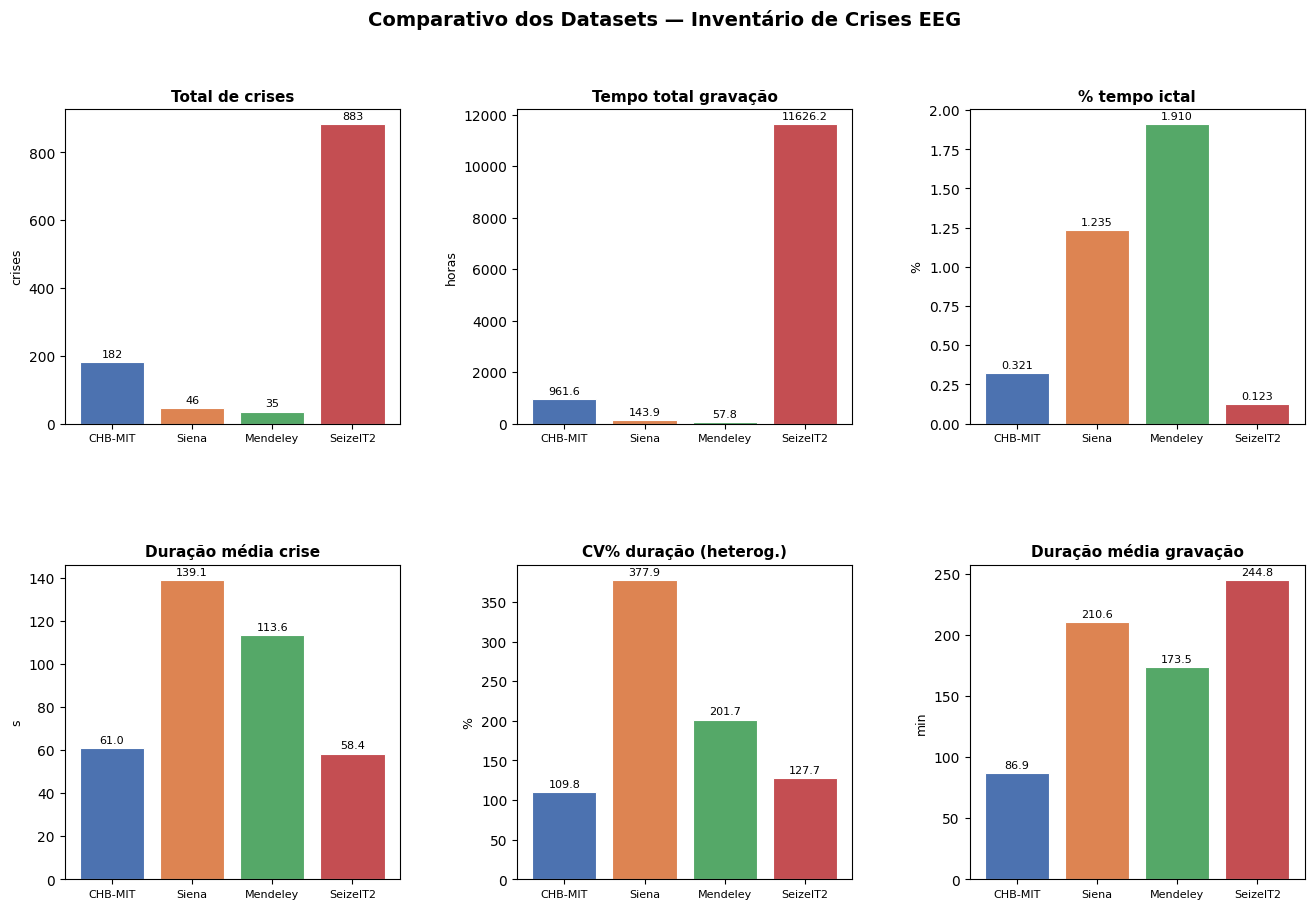

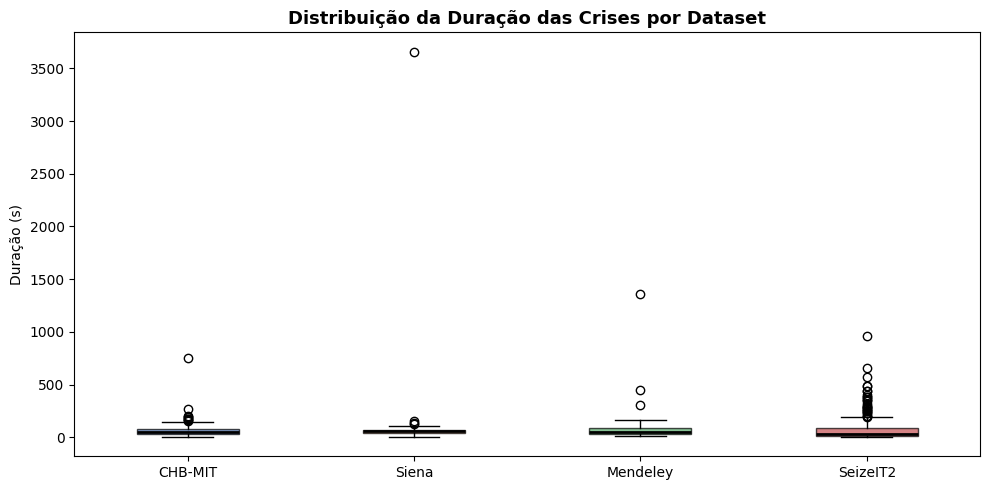

💾 Gráficos salvos em data\inventory


In [15]:
COLORS = {'CHB-MIT':'#4C72B0','Siena':'#DD8452','Mendeley':'#55A868','SeizeIT2':'#C44E52'}
datasets = list(df_summary.index); colors = [COLORS[d] for d in datasets]

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
axes = [fig.add_subplot(gs[r,c]) for r in range(2) for c in range(3)]

def bar(ax, col, title, ylabel, fmt='.0f'):
    vals = df_summary[col].fillna(0)
    bars = ax.bar(datasets, vals, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=9); ax.tick_params(axis='x', labelsize=8)
    mx = max(vals) if max(vals) > 0 else 1
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+mx*0.01,
                f'{v:{fmt}}', ha='center', va='bottom', fontsize=8)

bar(axes[0], 'total_seizures',     'Total de crises',        'crises')
bar(axes[1], 'total_rec_time_h',   'Tempo total gravação',   'horas',  '.1f')
bar(axes[2], 'pct_ictal',          '% tempo ictal',          '%',      '.3f')
bar(axes[3], 'seizure_dur_mean_s', 'Duração média crise',    's',      '.1f')
bar(axes[4], 'seizure_dur_cv_pct', 'CV% duração (heterog.)', '%',      '.1f')
bar(axes[5], 'rec_dur_mean_min',   'Duração média gravação', 'min',    '.1f')

fig.suptitle('Comparativo dos Datasets — Inventário de Crises EEG',
             fontsize=14, fontweight='bold')
plt.savefig(os.path.join(OUT_DIR, 'inventory_charts.png'), dpi=150, bbox_inches='tight')
plt.show()

# Boxplot de duração individual
def extract_durs(df):
    return [float(m) for _, row in df.iterrows()
            for m in re.findall(r'\((\d+(?:\.\d+)?)s\)', str(row['seizure_intervals']))
            if float(m) > 0]

fig2, ax2 = plt.subplots(figsize=(10, 5))
bp = ax2.boxplot([extract_durs(tables[d]) for d in datasets], labels=datasets,
                 patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, c in zip(bp['boxes'], colors): patch.set_facecolor(c); patch.set_alpha(0.7)
ax2.set_title('Distribuição da Duração das Crises por Dataset', fontsize=13, fontweight='bold')
ax2.set_ylabel('Duração (s)')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'seizure_duration_boxplot.png'), dpi=150, bbox_inches='tight')
plt.show()
print('💾 Gráficos salvos em', OUT_DIR)


---
## 9. ⬇️  Download de EDFs — OPCIONAL

> Execute apenas quando quiser baixar os sinais brutos para o NB1.
> Os downloads são grandes — veja os tamanhos estimados.
>
> | Sub-seção | Dataset | Pacientes | Escopo | Tamanho est. |
> |-----------|---------|-----------|--------|--------------|
> | 9.1 | CHB-MIT | 23 | Apenas EDFs com crise | ~15 GB |
> | 9.2 | Siena | 14 | Todos os EDFs | ~20 GB |
> | 9.3 | Mendeley | 6 | Todos os EDFs | ~3 GB |
> | 9.4 | SeizeIT2 | 23 | Apenas EDFs de runs com crise | ~25 GB |
>
> **Para rodar:** descomente a última linha de cada célula.


In [16]:
# # ── 9.1 CHB-MIT — apenas EDFs com crise, todos os 23 pacientes ───────────────
# def download_chbmit_edfs(patients=PATIENTS['CHBMIT'], root=CHBMIT_DIR):
#     s3 = s3_client()
#     rws = os.path.join(root, 'RECORDS-WITH-SEIZURES')
#     if not os.path.exists(rws):
#         print('⚠️  Execute a seção 1 primeiro (RECORDS-WITH-SEIZURES não encontrado).')
#         return
#     with open(rws) as f:
#         all_recs = [l.strip() for l in f if l.strip()]
#     for pat in patients:
#         seizure_recs = [r for r in all_recs if r.startswith(pat + '/')]
#         pat_dir = os.path.join(root, pat); os.makedirs(pat_dir, exist_ok=True)
#         for rec in tqdm(seizure_recs, desc=f'CHB-MIT {pat}', leave=False):
#             fname = rec.split('/')[-1]
#             local = os.path.join(pat_dir, fname)
#             if not os.path.exists(local):
#                 try: s3.download_file(CHBMIT_BUCKET, CHBMIT_PREFIX + rec, local)
#                 except Exception as e: print(f'  ⚠️  {rec}: {e}')
#         print(f'✅ CHB-MIT {pat} — {len(seizure_recs)} EDFs com crise')

# # download_chbmit_edfs()   # ← descomente para rodar
# print('9.1 CHB-MIT EDFs: descomente download_chbmit_edfs() para baixar.')


In [17]:
# # ── 9.2 Siena — todos os EDFs, todos os 14 pacientes ─────────────────────────
# def download_siena_edfs(patients=PATIENTS['Siena'], root=SIENA_DIR):
#     for pat in patients:
#         pat_dir  = os.path.join(root, pat)
#         base_url = SIENA_BASE + pat + '/'
#         try:
#             with urllib.request.urlopen(base_url, timeout=30) as r:
#                 content = r.read().decode('utf-8')
#         except Exception as e:
#             print(f'  ⚠️  {pat}: {e}'); continue
#         p = _LinkParser(); p.feed(content)
#         edf_files = [l for l in p.links if l.endswith('.edf')]
#         for fname in tqdm(edf_files, desc=f'Siena {pat}', leave=False):
#             local = os.path.join(pat_dir, fname)
#             if not os.path.exists(local):
#                 try: urllib.request.urlretrieve(base_url + fname, local)
#                 except Exception as e: print(f'  ⚠️  {fname}: {e}')
#         print(f'✅ Siena {pat} — {len(edf_files)} EDFs')

# # download_siena_edfs()   # ← descomente para rodar
# print('9.2 Siena EDFs: descomente download_siena_edfs() para baixar.')


In [18]:
# # ── 9.3 Mendeley — todos os EDFs, todos os 6 pacientes ───────────────────────
# def download_mendeley_edfs(patients=PATIENTS['Mendeley'], root=MENDELEY_DIR):
#     scraper = cloudscraper.create_scraper()
#     edf_dir = os.path.join(root, 'Raw_EDF_Files'); os.makedirs(edf_dir, exist_ok=True)
#     url = (f'https://data.mendeley.com/public-api/datasets/{MEND_DATASET_ID}'
#            f'/files?folder_id={MEND_EDF_FOLDER}&version={MEND_VERSION}')
#     r = scraper.get(url, headers=_MEND_HEADERS, timeout=30); r.raise_for_status()
#     def _keep(fn):
#         fn_l = fn.lower()
#         return any(fn_l.startswith(p.lower()+'_') or fn_l.startswith(p.lower()+'record')
#                    for p in patients)
#     targets = [f for f in r.json() if f['filename'].lower().endswith('.edf') and _keep(f['filename'])]
#     dl = 0
#     for fobj in tqdm(targets, desc='Mendeley EDFs'):
#         dst = os.path.join(edf_dir, fobj['filename'])
#         if not os.path.exists(dst):
#             with open(dst, 'wb') as f:
#                 f.write(scraper.get(fobj['content_details']['download_url'], timeout=120).content)
#             dl += 1
#     print(f'✅ Mendeley — {len(targets)} EDFs alvo | {dl} novos')

# # download_mendeley_edfs()   # ← descomente para rodar
# print('9.3 Mendeley EDFs: descomente download_mendeley_edfs() para baixar.')


In [19]:
# # ── 9.4 SeizeIT2 — apenas EDFs com crise, 23 primeiros sujeitos ──────────────
# # Mesmo número de pacientes que o CHB-MIT (23), conforme definido no projeto
# SEIZEIT_EDF_SUBJECTS = PATIENTS['SeizeIT2'][:23]  # sub-001..sub-023

# def download_seizeit2_edfs(subjects=SEIZEIT_EDF_SUBJECTS,
#                             root=SEIZEIT_DIR, session=SEIZEIT_SESSION):
#     s3 = s3_client(); total_dl = 0
#     for sub in tqdm(subjects, desc='SeizeIT2 EDFs'):
#         prefix  = f'{SEIZEIT_DATASET}/{sub}/{session}/eeg/'
#         sub_dir = os.path.join(root, sub, session, 'eeg')
#         os.makedirs(sub_dir, exist_ok=True)
#         # Descobre runs com crise a partir dos TSVs já baixados (seção 4)
#         seizure_runs = set()
#         for tsv in sorted(f for f in os.listdir(sub_dir) if f.endswith('_events.tsv')):
#             try:
#                 with open(os.path.join(sub_dir, tsv), 'rb') as f:
#                     if _tsv_has_seizure(f.read()):
#                         seizure_runs.add(tsv.replace('_events.tsv', ''))
#             except: pass
#         # Lista todas as chaves do sujeito no S3
#         try:
#             paginator = s3.get_paginator('list_objects_v2')
#             keys = []
#             for page in paginator.paginate(Bucket=SEIZEIT_BUCKET, Prefix=prefix):
#                 keys.extend(o['Key'] for o in page.get('Contents', []))
#         except Exception as e:
#             print(f'  ⚠️  {sub}: {e}'); continue
#         # Baixa apenas EDFs de runs com crise (igual ao NB1)
#         for key in tqdm(keys, desc=f'  {sub}', leave=False):
#             fname = key.split('/')[-1]
#             if not fname.endswith('_eeg.edf'): continue
#             run_prefix = fname.replace('_eeg.edf','')
#             if run_prefix not in seizure_runs: continue
#             local = os.path.join(sub_dir, fname)
#             if not os.path.exists(local):
#                 try: s3.download_file(SEIZEIT_BUCKET, key, local); total_dl += 1
#                 except Exception as e: print(f'  ⚠️  {fname}: {e}')
#         print(f'  ✅ {sub} — {len(seizure_runs)} runs com crise')
#     print(f'\n✅ SeizeIT2 EDFs — {total_dl} arquivos novos')

# # download_seizeit2_edfs()   # ← descomente para rodar
# print('9.4 SeizeIT2 EDFs: descomente download_seizeit2_edfs() para baixar.')


---
## 10. Análise por paciente — subtabelas e Top 6

> Lê os CSVs já salvos em `data/inventory/` — **não baixa nada de novo**.
> Pré-requisito: seções 1–6 já executadas.


In [20]:
import os, re, io, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import IPython.display as ipd
warnings.filterwarnings('ignore')

OUT_DIR = os.path.join('data', 'inventory')

def _load(tag):
    p = os.path.join(OUT_DIR, f'inventory_{tag}.csv')
    if os.path.exists(p): return pd.read_csv(p)
    print(f'⚠️  {p} não encontrado — execute as seções 1-6 primeiro.')
    return pd.DataFrame()

df_chbmit   = _load('chb_mit')
df_siena    = _load('siena')
df_mendeley = _load('mendeley')
df_seizeit  = _load('seizeit2')

tables = {'CHB-MIT': df_chbmit, 'Siena': df_siena,
          'Mendeley': df_mendeley, 'SeizeIT2': df_seizeit}

for name, df in tables.items():
    print(f'✅ {name:10} — {len(df):4d} gravações | {int(df["n_seizures"].sum())} crises')


✅ CHB-MIT    —  664 gravações | 182 crises
✅ Siena      —   41 gravações | 46 crises
✅ Mendeley   —   20 gravações | 35 crises
✅ SeizeIT2   — 2850 gravações | 883 crises


In [21]:
# ── Helpers ───────────────────────────────────────────────────────────────────

def extract_sz_durations(si_str):
    """Extrai lista de durações individuais de crise da coluna seizure_intervals."""
    return [float(m) for m in re.findall(r'\((\d+(?:\.\d+)?)s\)', str(si_str))
            if float(m) > 0]

def classify_recording(duration_s, si_str, window_s=300):
    """
    Classifica o tempo de uma gravação em 4 classes (em segundos):
      ictal        — durante a crise
      pre_ictal    — até window_s segundos ANTES de cada crise (inter-ictal-antes)
      post_ictal   — até window_s segundos DEPOIS de cada crise (inter-ictal-depois)
      interictal   — restante (longe de crises)
    """
    dur = float(duration_s) if not pd.isna(duration_s) else 0.0
    pairs = re.findall(r'(\d+(?:\.\d+)?)s\u2013(\d+(?:\.\d+)?)s', str(si_str))
    if not pairs:
        return {'ictal': 0.0, 'pre_ictal': 0.0, 'post_ictal': 0.0, 'interictal': dur}
    ictal = sum(float(e) - float(o) for o, e in pairs)
    pre   = sum(min(float(o), window_s) for o, _ in pairs)
    post  = sum(min(max(dur - float(e), 0.0), window_s) for _, e in pairs)
    inter = max(0.0, dur - ictal - pre - post)
    return {'ictal': ictal, 'pre_ictal': pre, 'post_ictal': post, 'interictal': inter}

def per_patient_table(df, ds_name):
    """Agrega métricas por paciente — uma linha por paciente."""
    rows = []
    for pat, grp in df.groupby('patient'):
        total_s  = grp['duration_s'].dropna().sum()
        durs     = [d for _, r in grp.iterrows()
                    for d in extract_sz_durations(r['seizure_intervals'])]
        cls = {'ictal':0.0,'pre_ictal':0.0,'post_ictal':0.0,'interictal':0.0}
        for _, r in grp.iterrows():
            for k, v in classify_recording(r['duration_s'], r['seizure_intervals']).items():
                cls[k] += v
        rows.append({
            'dataset'                   : ds_name,
            'patient'                   : pat,
            # gravações
            'n_recordings'              : len(grp),
            'n_rec_with_seizure'        : int((grp['n_seizures'] > 0).sum()),
            # tempo total de gravação
            'total_rec_s'               : round(total_s, 1),
            'total_rec_min'             : round(total_s / 60,   1),
            'total_rec_h'               : round(total_s / 3600, 3),
            # duração média/mediana por gravação
            'mean_rec_s'                : round(grp['duration_s'].mean(),    1),
            'mean_rec_min'              : round(grp['duration_min'].mean(),  1),
            'median_rec_s'              : round(grp['duration_s'].median(),  1),
            'median_rec_min'            : round(grp['duration_min'].median(),1),
            # crises
            'total_seizures'            : int(grp['n_seizures'].sum()),
            'total_ictal_s'             : round(grp['total_ictal_s'].sum(), 1),
            'total_ictal_min'           : round(grp['total_ictal_s'].sum() / 60,   2),
            'total_ictal_h'             : round(grp['total_ictal_s'].sum() / 3600, 4),
            'pct_ictal'                 : round(grp['total_ictal_s'].sum() / total_s * 100, 3)
                                          if total_s > 0 else 0.0,
            # duração individual de crise
            'mean_sz_dur_s'             : round(np.mean(durs),   1) if durs else None,
            'median_sz_dur_s'           : round(np.median(durs), 1) if durs else None,
            'min_sz_dur_s'              : round(min(durs), 1) if durs else None,
            'max_sz_dur_s'              : round(max(durs), 1) if durs else None,
            # classes — segundos
            'class_ictal_s'             : round(cls['ictal'],      1),
            'class_pre_ictal_s'         : round(cls['pre_ictal'],  1),
            'class_post_ictal_s'        : round(cls['post_ictal'], 1),
            'class_interictal_s'        : round(cls['interictal'], 1),
            # classes — minutos
            'class_ictal_min'           : round(cls['ictal']      / 60, 2),
            'class_pre_ictal_min'       : round(cls['pre_ictal']  / 60, 2),
            'class_post_ictal_min'      : round(cls['post_ictal'] / 60, 2),
            'class_interictal_min'      : round(cls['interictal'] / 60, 2),
            # classes — horas
            'class_ictal_h'             : round(cls['ictal']      / 3600, 4),
            'class_pre_ictal_h'         : round(cls['pre_ictal']  / 3600, 4),
            'class_post_ictal_h'        : round(cls['post_ictal'] / 3600, 4),
            'class_interictal_h'        : round(cls['interictal'] / 3600, 4),
        })
    return pd.DataFrame(rows)

print('✅ Helpers definidos (janela pré/pós-ictal = 300 s = 5 min)')


✅ Helpers definidos (janela pré/pós-ictal = 300 s = 5 min)


### 10.2 Subtabelas por paciente

In [22]:
pp = {}   # per-patient DataFrames
for ds_name, df in tables.items():
    if df.empty: continue
    df_pp = per_patient_table(df, ds_name)
    pp[ds_name] = df_pp
    csv_path = os.path.join(OUT_DIR, f'per_patient_{ds_name.lower().replace("-","_")}.csv')
    df_pp.to_csv(csv_path, index=False)
    print(f'\n{"="*55}')
    print(f'  {ds_name}  ({len(df_pp)} pacientes)')
    print(f'{"="*55}')
    if len(df_pp) > 20:
        print(f'  (exibindo resumo estatístico — {len(df_pp)} linhas salvas em {csv_path})')
        ipd.display(df_pp.describe().round(2))
        print('\nPrimeiras 5 linhas:')
        ipd.display(df_pp.head())
    else:
        ipd.display(df_pp)
    print(f'💾 {csv_path}')



  CHB-MIT  (23 pacientes)
  (exibindo resumo estatístico — 23 linhas salvas em data\inventory\per_patient_chb_mit.csv)


,n_recordings,n_rec_with_seizure,total_rec_s,total_rec_min,total_rec_h,mean_rec_s,mean_rec_min,median_rec_s,median_rec_min,total_seizures,total_ictal_s,total_ictal_min,total_ictal_h,pct_ictal,mean_sz_dur_s,median_sz_dur_s,min_sz_dur_s,max_sz_dur_s,class_ictal_s,class_pre_ictal_s,class_post_ictal_s,class_interictal_s,class_ictal_min,class_pre_ictal_min,class_post_ictal_min,class_interictal_min,class_ictal_h,class_pre_ictal_h,class_post_ictal_h,class_interictal_h
count,23.00,23.00,23.00,23.00,23.00,23.00,23.00,23.00,23.00,23.00,23.00,23.00,23.00,23.00,23.00,23.00,23.00,23.00,23.00,23.00,23.00,23.00,23.00,23.00,23.00,23.00,23.00,23.00,23.00,23.00
mean,28.87,5.61,150517.39,2508.63,41.81,5687.73,94.79,6025.52,100.43,7.91,482.61,8.04,0.13,0.41,76.00,65.11,42.35,123.61,482.61,2328.96,2274.13,145441.65,8.04,38.82,37.90,2424.03,0.13,0.65,0.63,40.40
std,9.11,3.06,103185.32,1719.75,28.66,3821.90,63.69,4395.11,73.25,8.02,449.14,7.49,0.12,0.44,56.55,36.72,33.99,147.43,449.14,2337.93,2259.03,104144.34,7.49,38.97,37.65,1735.74,0.12,0.65,0.63,28.93
min,9.00,3.00,68400.00,1140.00,19.00,3426.40,57.10,3600.00,60.00,3.00,84.00,1.40,0.02,0.06,8.40,8.00,6.00,14.00,84.00,730.00,694.00,61147.00,1.40,12.17,11.57,1019.12,0.02,0.20,0.19,16.99
25%,20.50,3.00,97488.00,1624.80,27.08,3580.15,59.65,3600.00,60.00,3.50,220.00,3.66,0.06,0.15,47.20,43.50,15.50,69.50,220.00,1050.00,1050.00,92732.00,3.66,17.50,17.50,1545.53,0.06,0.29,0.29,25.76
50%,30.00,5.00,125257.00,2087.60,34.79,3600.20,60.00,3600.00,60.00,6.00,325.00,5.42,0.09,0.25,63.10,62.00,30.00,82.00,325.00,1800.00,1500.00,122653.00,5.42,30.00,25.00,2044.22,0.09,0.50,0.42,34.07
75%,36.00,7.00,145012.00,2416.85,40.28,5402.30,90.05,5400.00,90.00,8.00,491.00,8.18,0.14,0.42,96.10,85.00,60.00,115.50,491.00,2297.00,2400.00,139099.00,8.18,38.28,40.00,2318.32,0.14,0.64,0.67,38.64
max,42.00,14.00,561834.00,9363.90,156.06,13377.00,222.90,14400.00,240.00,40.00,1992.00,33.20,0.55,1.73,268.70,171.00,134.00,752.00,1992.00,11641.00,11266.00,559056.00,33.20,194.02,187.77,9317.60,0.55,3.23,3.13,155.29



Primeiras 5 linhas:


,dataset,patient,n_recordings,n_rec_with_seizure,total_rec_s,total_rec_min,total_rec_h,mean_rec_s,mean_rec_min,median_rec_s,median_rec_min,total_seizures,total_ictal_s,total_ictal_min,total_ictal_h,pct_ictal,mean_sz_dur_s,median_sz_dur_s,min_sz_dur_s,max_sz_dur_s,class_ictal_s,class_pre_ictal_s,class_post_ictal_s,class_interictal_s,class_ictal_min,class_pre_ictal_min,class_post_ictal_min,class_interictal_min,class_ictal_h,class_pre_ictal_h,class_post_ictal_h,class_interictal_h
0,CHB-MIT,chb01,42,7,145988,2433.10,40.55,3475.90,57.90,3600.00,60.00,7,442,7.37,0.12,0.30,63.10,51.00,27.00,101.00,442.00,2100.00,2100.00,141346.00,7.37,35.00,35.00,2355.77,0.12,0.58,0.58,39.26
1,CHB-MIT,chb02,36,3,126959,2116.00,35.27,3526.60,58.80,3600.00,60.00,3,172,2.87,0.05,0.14,57.30,81.00,9.00,82.00,172.00,730.00,822.00,125235.00,2.87,12.17,13.70,2087.25,0.05,0.20,0.23,34.79
2,CHB-MIT,chb03,38,7,136806,2280.10,38.00,3600.20,60.00,3600.00,60.00,7,402,6.70,0.11,0.29,57.40,53.00,47.00,69.00,402.00,2100.00,2100.00,132204.00,6.70,35.00,35.00,2203.40,0.11,0.58,0.58,36.72
3,CHB-MIT,chb04,42,3,561834,9363.90,156.06,13377.00,222.90,14400.00,240.00,4,378,6.30,0.10,0.07,94.50,106.50,49.00,116.00,378.00,1200.00,1200.00,559056.00,6.30,20.00,20.00,9317.60,0.10,0.33,0.33,155.29
4,CHB-MIT,chb05,39,5,140410,2340.20,39.00,3600.30,60.00,3600.00,60.00,5,558,9.30,0.15,0.40,111.60,115.00,96.00,120.00,558.00,1500.00,1500.00,136852.00,9.30,25.00,25.00,2280.87,0.15,0.42,0.42,38.01


💾 data\inventory\per_patient_chb_mit.csv

  Siena  (14 pacientes)


...

💾 data\inventory\per_patient_mendeley.csv

  SeizeIT2  (125 pacientes)
  (exibindo resumo estatístico — 125 linhas salvas em data\inventory\per_patient_seizeit2.csv)


,n_recordings,n_rec_with_seizure,total_rec_s,total_rec_min,total_rec_h,mean_rec_s,mean_rec_min,median_rec_s,median_rec_min,total_seizures,total_ictal_s,total_ictal_min,total_ictal_h,pct_ictal,mean_sz_dur_s,median_sz_dur_s,min_sz_dur_s,max_sz_dur_s,class_ictal_s,class_pre_ictal_s,class_post_ictal_s,class_interictal_s,class_ictal_min,class_pre_ictal_min,class_post_ictal_min,class_interictal_min,class_ictal_h,class_pre_ictal_h,class_post_ictal_h,class_interictal_h
count,125.00,125.00,125.00,125.00,125.00,125.00,125.00,125.00,125.00,125.00,125.00,125.00,125.00,125.00,125.00,125.00,125.00,125.00,125.00,125.00,125.00,125.00,125.00,125.00,125.00,125.00,125.00,125.00,125.00,125.00
mean,22.80,3.16,334835.97,5580.60,93.01,30684.02,511.40,29492.74,491.55,7.06,412.60,6.88,0.11,0.33,90.17,85.28,63.34,133.10,412.60,2073.26,2065.50,330292.09,6.88,34.55,34.42,5504.87,0.11,0.58,0.57,91.75
std,28.82,3.45,190483.80,3174.73,52.91,17746.55,295.77,21675.56,361.26,12.82,744.04,12.40,0.21,1.38,96.69,93.75,90.37,137.19,744.04,3794.32,3791.42,189654.39,12.40,63.24,63.19,3160.91,0.21,1.05,1.05,52.68
min,1.00,1.00,3812.00,63.50,1.06,762.40,12.70,772.00,12.90,1.00,12.00,0.20,0.00,0.00,7.50,6.50,2.00,8.00,12.00,300.00,49.00,829.00,0.20,5.00,0.82,13.82,0.00,0.08,0.01,0.23
25%,7.00,1.00,240097.00,4001.60,66.69,17062.40,284.40,15423.00,257.00,2.00,109.00,1.82,0.03,0.04,41.00,35.00,19.00,55.00,109.00,600.00,593.00,227711.00,1.82,10.00,9.88,3795.18,0.03,0.17,0.16,63.25
50%,10.00,2.00,341981.00,5699.70,95.00,35341.20,589.00,22371.00,372.80,3.00,214.00,3.57,0.06,0.07,65.00,64.00,36.00,97.00,214.00,900.00,900.00,334251.00,3.57,15.00,15.00,5570.85,0.06,0.25,0.25,92.85
75%,25.00,4.00,408008.00,6800.10,113.34,41559.70,692.70,37907.00,631.80,7.00,452.00,7.53,0.13,0.16,107.50,101.00,78.00,149.00,452.00,2100.00,1801.00,403772.00,7.53,35.00,30.02,6729.53,0.13,0.58,0.50,112.16
max,120.00,26.00,1429612.00,23826.90,397.11,76069.00,1267.80,79782.00,1329.70,75.00,7260.00,121.00,2.02,13.18,661.00,661.00,661.00,962.00,7260.00,22500.00,22500.00,1428351.00,121.00,375.00,375.00,23805.85,2.02,6.25,6.25,396.76



Primeiras 5 linhas:


,dataset,patient,n_recordings,n_rec_with_seizure,total_rec_s,total_rec_min,total_rec_h,mean_rec_s,mean_rec_min,median_rec_s,median_rec_min,total_seizures,total_ictal_s,total_ictal_min,total_ictal_h,pct_ictal,mean_sz_dur_s,median_sz_dur_s,min_sz_dur_s,max_sz_dur_s,class_ictal_s,class_pre_ictal_s,class_post_ictal_s,class_interictal_s,class_ictal_min,class_pre_ictal_min,class_post_ictal_min,class_interictal_min,class_ictal_h,class_pre_ictal_h,class_post_ictal_h,class_interictal_h
0,SeizeIT2,sub-001,9,4,383679.00,6394.60,106.58,42631.00,710.50,48657.00,811.00,4,321.00,5.35,0.09,0.08,80.20,76.50,25.00,143.00,321.00,1200.00,1200.00,380958.00,5.35,20.00,20.00,6349.30,0.09,0.33,0.33,105.82
1,SeizeIT2,sub-002,12,7,357061.00,5951.00,99.18,29755.10,495.90,19895.00,331.60,15,1820.00,30.33,0.51,0.51,121.30,118.00,20.00,228.00,1820.00,4500.00,4110.00,346631.00,30.33,75.00,68.50,5777.18,0.51,1.25,1.14,96.29
2,SeizeIT2,sub-003,10,1,413688.00,6894.80,114.91,41368.80,689.50,36660.50,611.00,1,55.00,0.92,0.02,0.01,55.00,55.00,55.00,55.00,55.00,300.00,300.00,413033.00,0.92,5.00,5.00,6883.88,0.02,0.08,0.08,114.73
3,SeizeIT2,sub-004,1,1,66600.00,1110.00,18.50,66600.00,1110.00,66600.00,1110.00,4,314.00,5.23,0.09,0.47,78.50,83.00,42.00,106.00,314.00,1200.00,1200.00,63886.00,5.23,20.00,20.00,1064.77,0.09,0.33,0.33,17.75
4,SeizeIT2,sub-005,26,2,436370.00,7272.80,121.21,16783.50,279.70,6818.00,113.60,2,305.00,5.08,0.08,0.07,152.50,152.50,151.00,154.00,305.00,600.00,600.00,434865.00,5.08,10.00,10.00,7247.75,0.08,0.17,0.17,120.80


💾 data\inventory\per_patient_seizeit2.csv


### 10.3 Gráficos Top 6 por dataset

Cada painel mostra os **6 pacientes no topo** de 5 critérios:
1. Mais crises
2. Mais horas gravadas
3. Maior % ictal
4. Maior tempo ictal absoluto (horas)
5. Crises mais longas (duração média em segundos)

> Para o Mendeley (6 pacientes) o Top 6 = todos os pacientes.


In [23]:
COLORS = {
    'CHB-MIT'  : '#4C72B0',
    'Siena'    : '#DD8452',
    'Mendeley' : '#55A868',
    'SeizeIT2' : '#C44E52',
}

RANKINGS = [
    ('total_seizures',  'Mais crises',               'Nº de crises',        False),
    ('total_rec_h',     'Mais horas gravadas',        'Horas gravadas',      False),
    ('pct_ictal',       'Maior % ictal',              '% ictal',             False),
    ('total_ictal_h',   'Maior tempo ictal (h abs.)', 'Horas ictais',        False),
    ('mean_sz_dur_s',   'Crises mais longas (média)', 'Duração média (s)',   False),
]
TOP_N = 6

def plot_top6(ax, df_pp, col, title, xlabel, ds_name, color):
    """Barra horizontal com Top 6 pacientes para uma métrica."""
    sub = df_pp[['patient', col]].dropna().sort_values(col, ascending=False).head(TOP_N)
    sub = sub.iloc[::-1]   # inverte para o maior ficar no topo
    bars = ax.barh(sub['patient'], sub[col], color=color, alpha=0.85,
                   edgecolor='white', linewidth=0.6, height=0.6)
    ax.set_title(title, fontsize=9, fontweight='bold', pad=4)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.tick_params(axis='x', labelsize=7)
    ax.spines[['top','right']].set_visible(False)
    # Rótulos nas barras
    mx = sub[col].max() if sub[col].max() > 0 else 1
    for bar, val in zip(bars, sub[col]):
        fmt = f'{val:.1f}' if val < 100 else f'{val:.0f}'
        ax.text(bar.get_width() + mx * 0.02, bar.get_y() + bar.get_height()/2,
                fmt, va='center', fontsize=7)
    ax.set_xlim(0, mx * 1.18)

print('✅ Função plot_top6 definida')


✅ Função plot_top6 definida


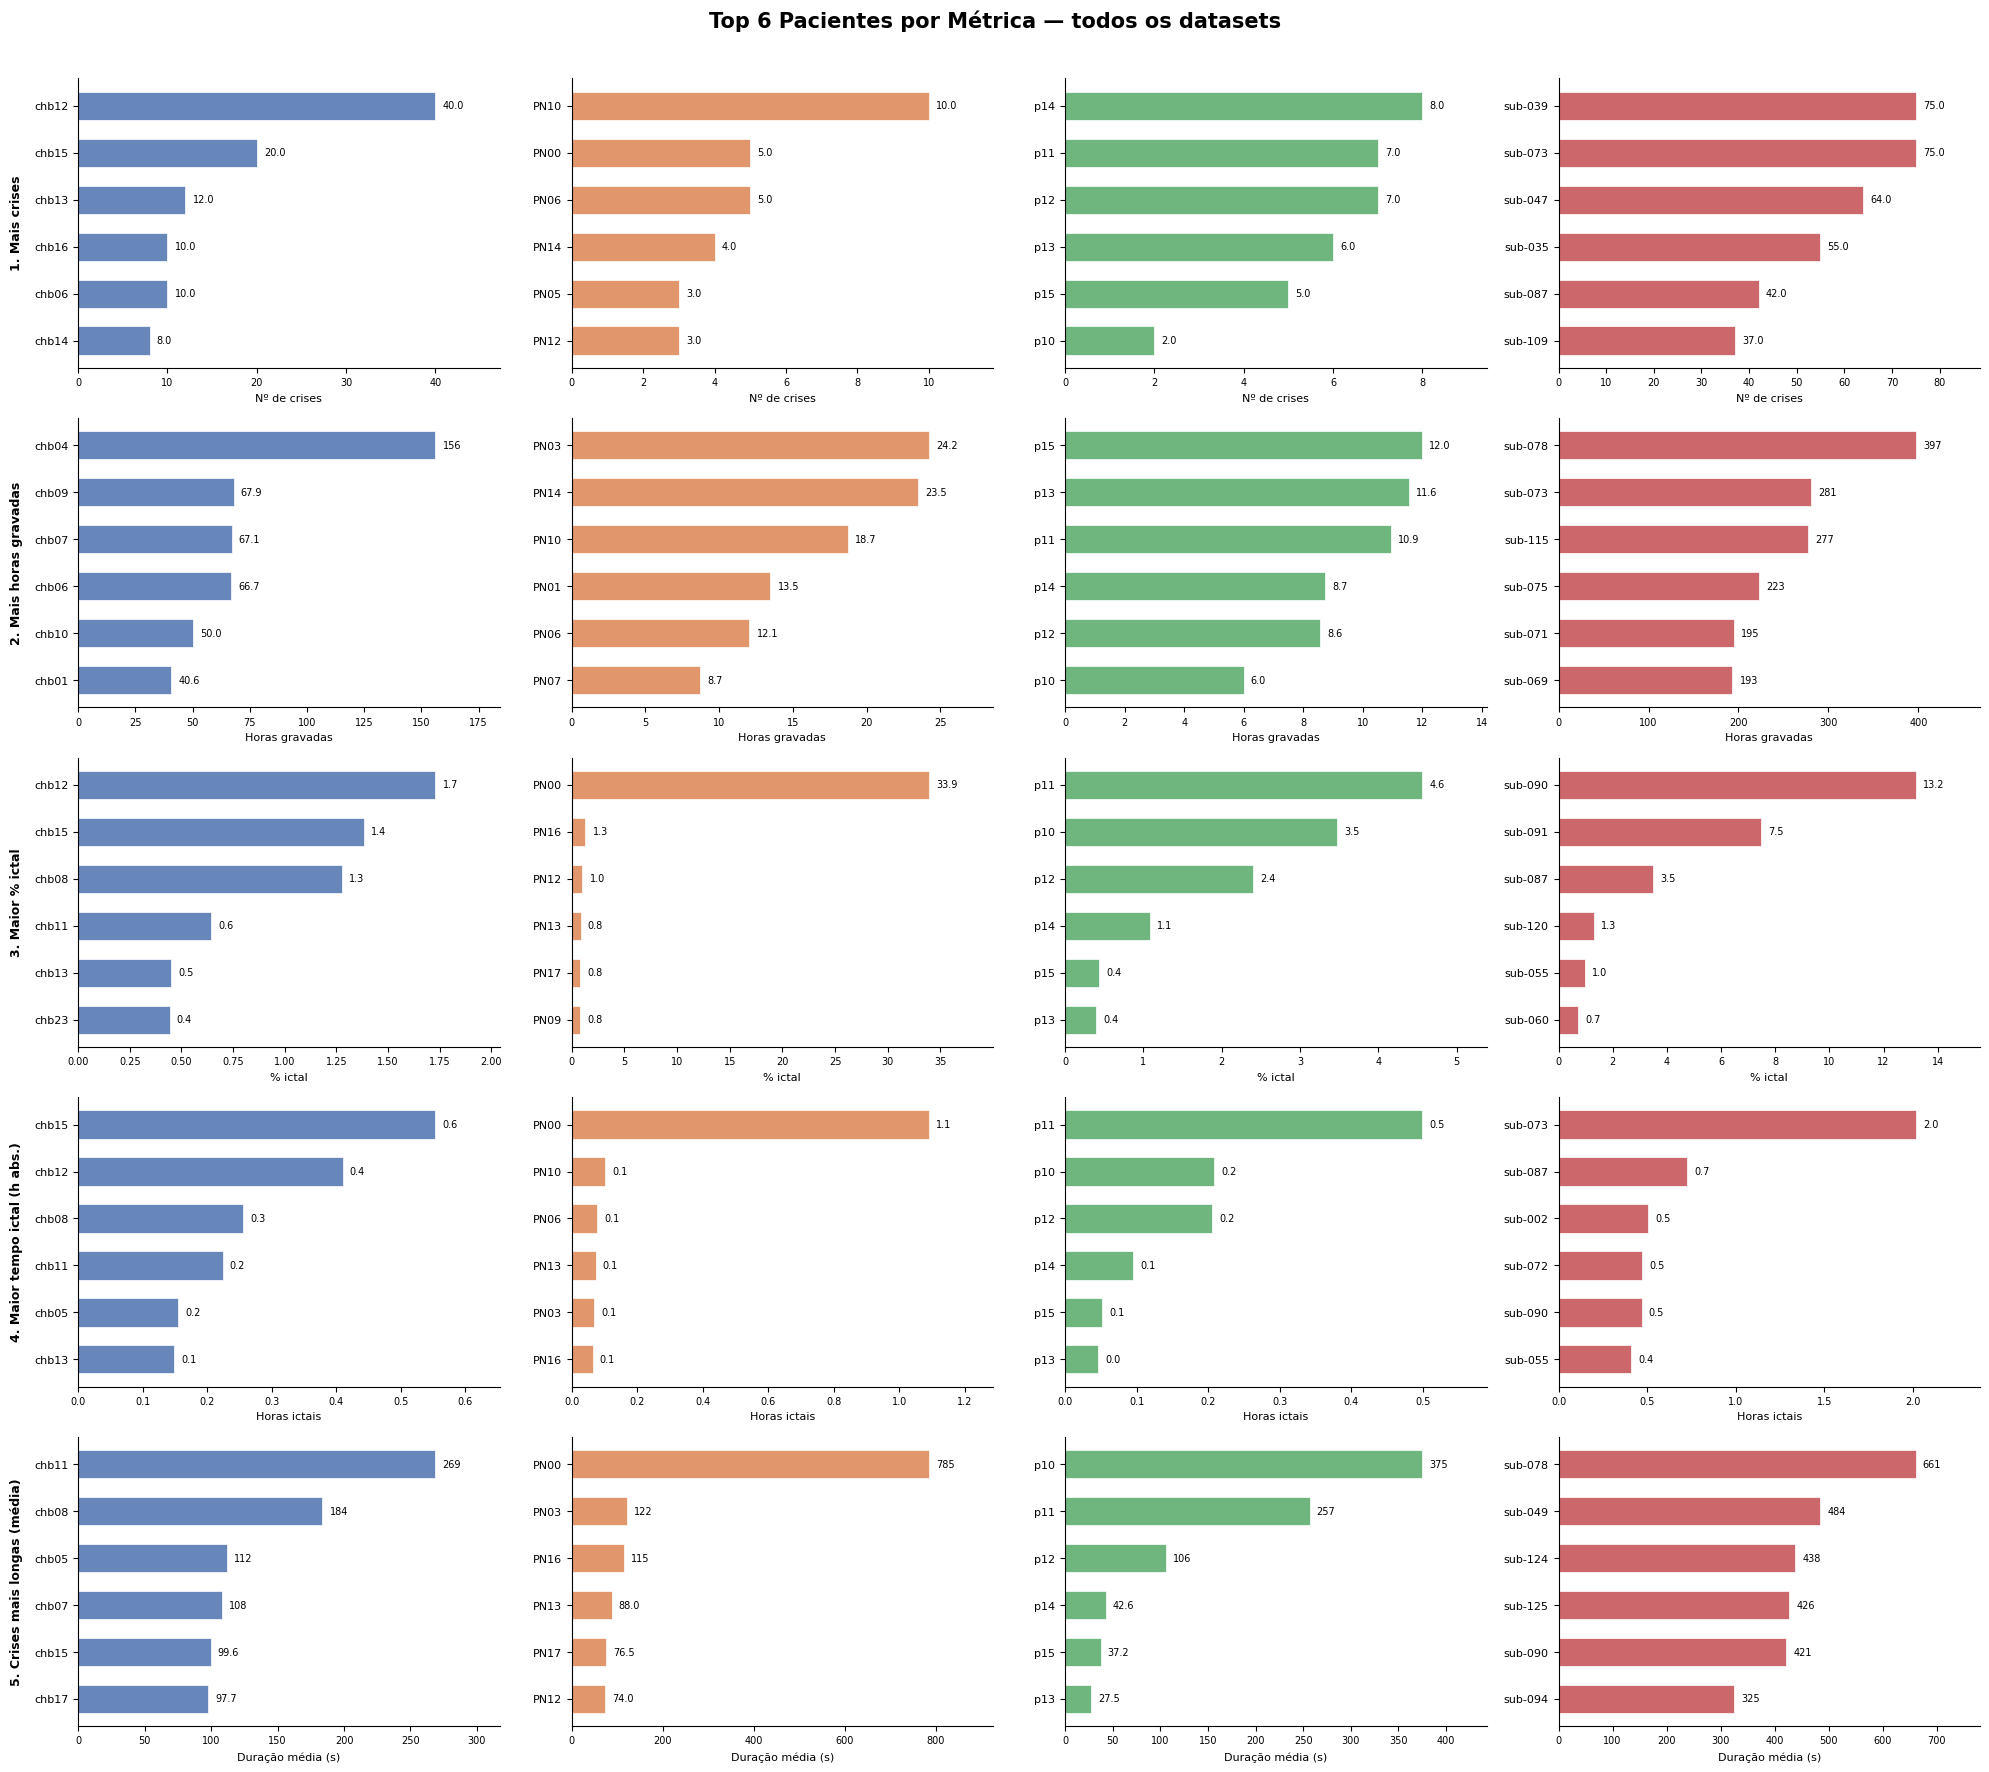

💾 data\inventory\top6_all_datasets.png


In [24]:
# ── Figura principal: 5 rankings × 4 datasets ─────────────────────────────────
n_ds  = len(pp)
n_met = len(RANKINGS)
fig, axes = plt.subplots(n_met, n_ds, figsize=(5 * n_ds, 3.5 * n_met))
fig.suptitle('Top 6 Pacientes por Métrica — todos os datasets',
             fontsize=15, fontweight='bold', y=1.01)

for col_i, (ds_name, df_pp) in enumerate(pp.items()):
    color = COLORS[ds_name]
    axes[0, col_i].set_title(f'\n{ds_name}', fontsize=11, fontweight='bold', pad=14)

    for row_i, (col, title, xlabel, _) in enumerate(RANKINGS):
        ax = axes[row_i, col_i]

        # Adiciona título da métrica apenas na coluna 0
        row_label = f'{row_i+1}. {title}'
        if col_i == 0:
            ax.set_ylabel(row_label, fontsize=9, fontweight='bold', labelpad=8)

        if col not in df_pp.columns or df_pp[col].dropna().empty:
            ax.set_visible(False)
            continue

        plot_top6(ax, df_pp, col, '', xlabel, ds_name, color)

plt.tight_layout()
out = os.path.join(OUT_DIR, 'top6_all_datasets.png')
plt.savefig(out, dpi=140, bbox_inches='tight')
plt.show()
print(f'💾 {out}')


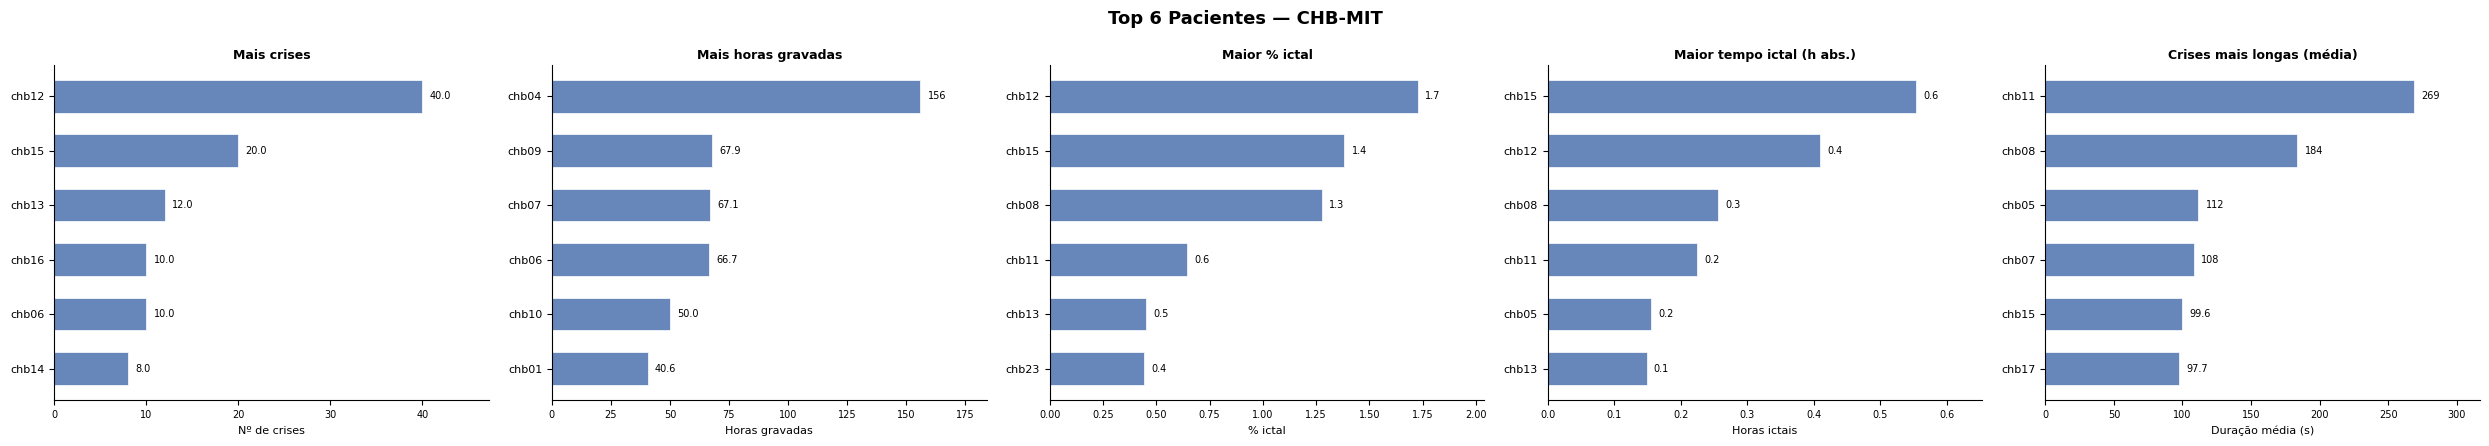

💾 data\inventory\top6_chb_mit.png


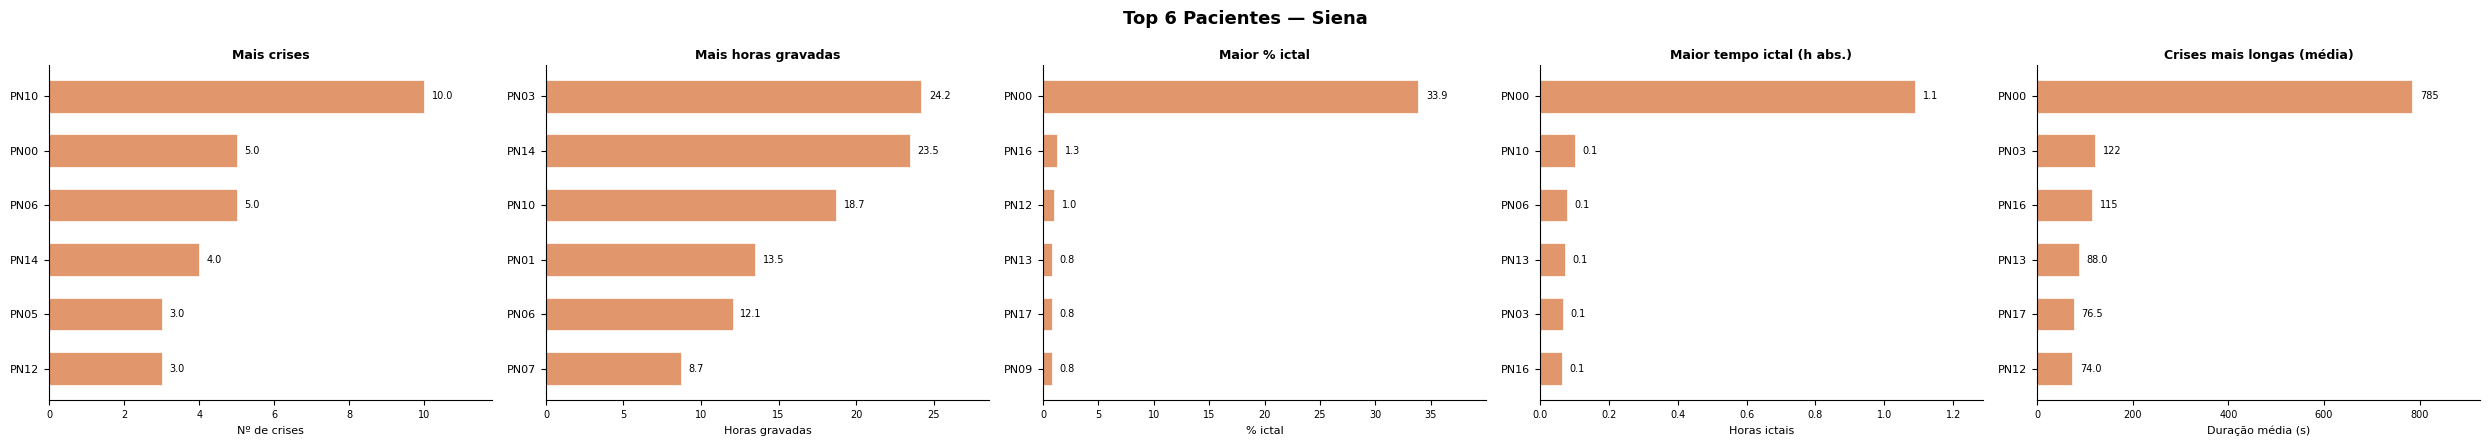

💾 data\inventory\top6_siena.png


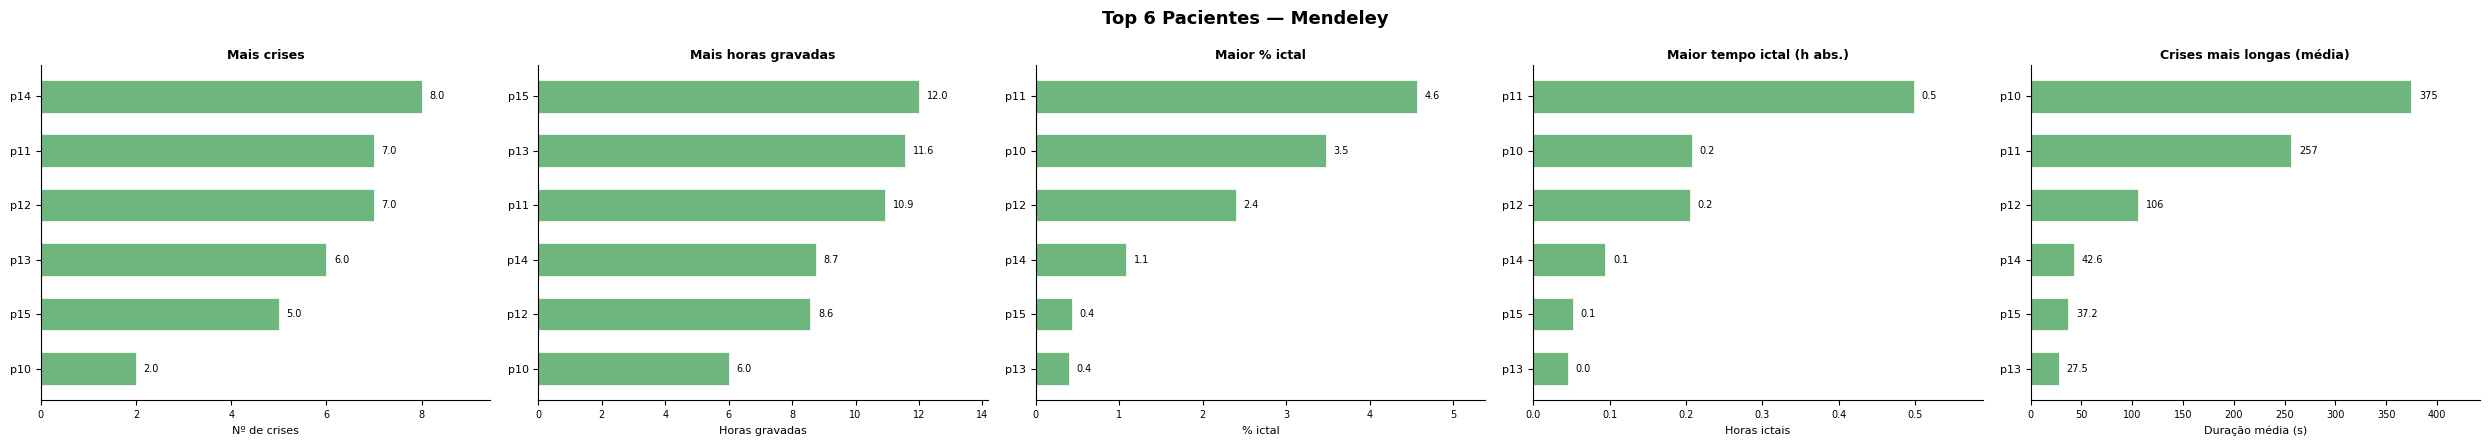

💾 data\inventory\top6_mendeley.png


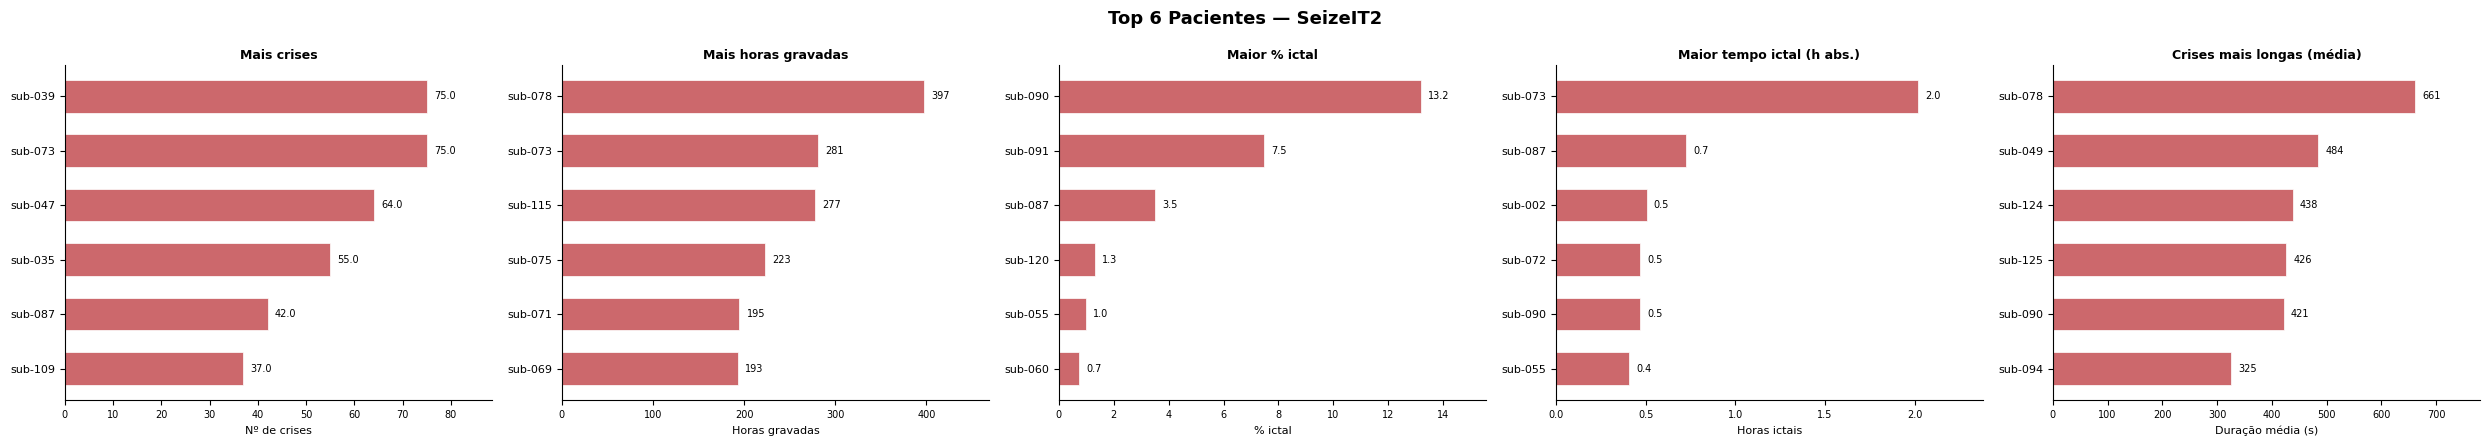

💾 data\inventory\top6_seizeit2.png


In [25]:
# ── Figuras individuais por dataset (uma por dataset, 5 rankings em coluna) ───
for ds_name, df_pp in pp.items():
    color = COLORS[ds_name]
    fig, axes = plt.subplots(1, len(RANKINGS), figsize=(5 * len(RANKINGS), 4.5))
    fig.suptitle(f'Top {TOP_N} Pacientes — {ds_name}',
                 fontsize=13, fontweight='bold')

    for ax, (col, title, xlabel, _) in zip(axes, RANKINGS):
        if col not in df_pp.columns or df_pp[col].dropna().empty:
            ax.set_visible(False); continue
        plot_top6(ax, df_pp, col, title, xlabel, ds_name, color)

    plt.tight_layout()
    out = os.path.join(OUT_DIR, f'top6_{ds_name.lower().replace("-","_")}.png')
    plt.savefig(out, dpi=140, bbox_inches='tight')
    plt.show()
    print(f'💾 {out}')


### 10.4 Distribuição de classes — Top 6 pacientes com mais crises

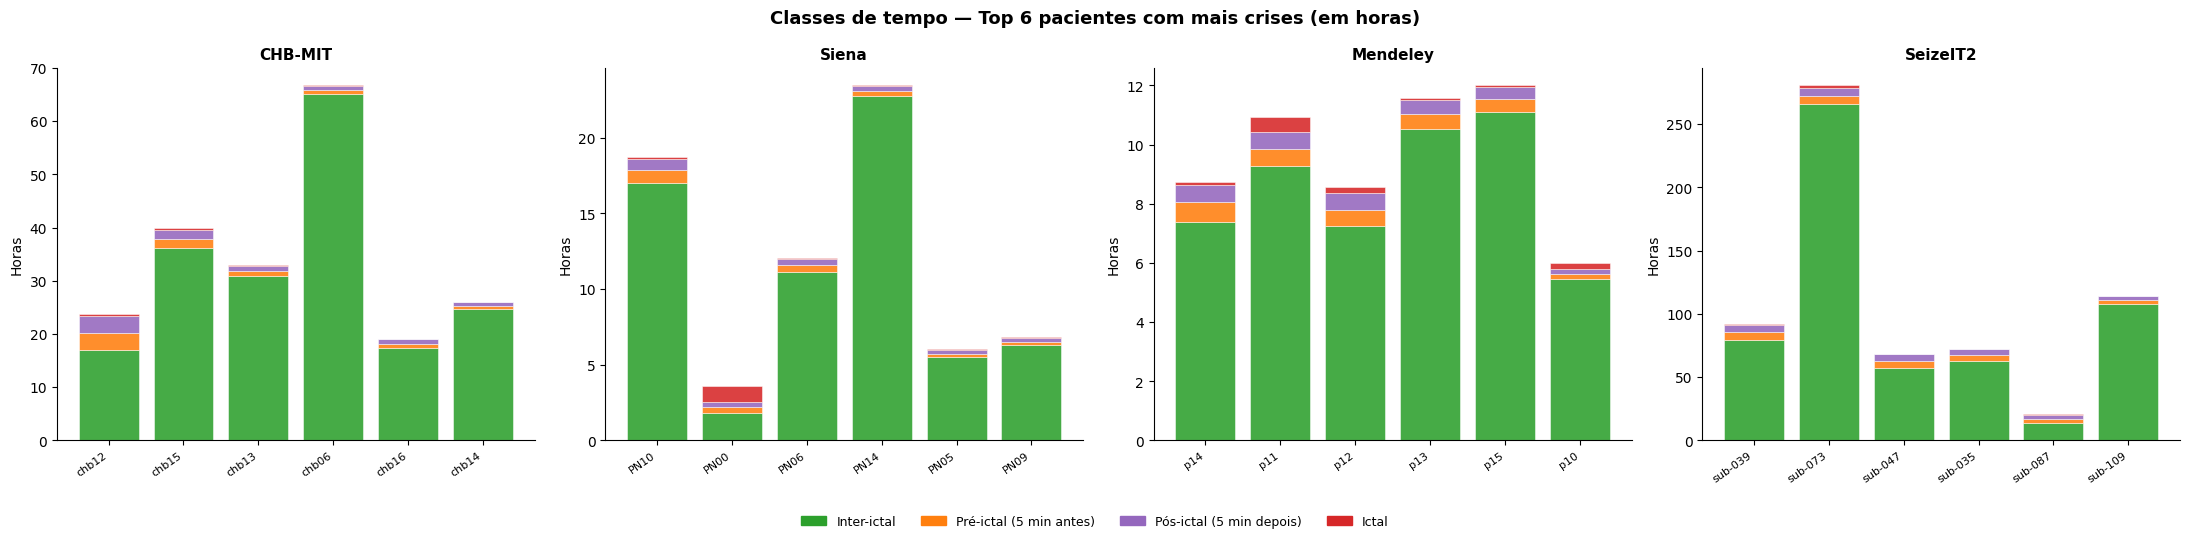

💾 data\inventory\classes_top6.png


In [26]:
CLS_COLORS = {
    'interictal' : '#2ca02c',
    'pre_ictal'  : '#ff7f0e',
    'post_ictal' : '#9467bd',
    'ictal'      : '#d62728',
}
CLS_LABELS = {
    'interictal' : 'Inter-ictal',
    'pre_ictal'  : 'Pré-ictal (5 min antes)',
    'post_ictal' : 'Pós-ictal (5 min depois)',
    'ictal'      : 'Ictal',
}

fig, axes = plt.subplots(1, len(pp), figsize=(5.5 * len(pp), 5))
fig.suptitle(f'Classes de tempo — Top {TOP_N} pacientes com mais crises (em horas)',
             fontsize=13, fontweight='bold')

for ax, (ds_name, df_pp) in zip(axes, pp.items()):
    top = df_pp.nlargest(TOP_N, 'total_seizures')
    pats = top['patient'].tolist()
    x = np.arange(len(pats))
    bottom = np.zeros(len(pats))

    for key in ['interictal', 'pre_ictal', 'post_ictal', 'ictal']:
        col = f'class_{key}_h'
        if col not in top.columns: continue
        vals = top[col].fillna(0).values
        ax.bar(x, vals, bottom=bottom, color=CLS_COLORS[key],
               label=CLS_LABELS[key], alpha=0.88, edgecolor='white', linewidth=0.4)
        bottom += vals

    ax.set_title(ds_name, fontsize=11, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(pats, rotation=35, ha='right', fontsize=8)
    ax.set_ylabel('Horas'); ax.spines[['top','right']].set_visible(False)

# Legenda única
handles = [mpatches.Patch(color=CLS_COLORS[k], label=CLS_LABELS[k])
           for k in ['interictal','pre_ictal','post_ictal','ictal']]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.08), frameon=False)

plt.tight_layout()
out = os.path.join(OUT_DIR, 'classes_top6.png')
plt.savefig(out, dpi=140, bbox_inches='tight')
plt.show()
print(f'💾 {out}')


### 10.5 Scatter — horas gravadas × número de crises

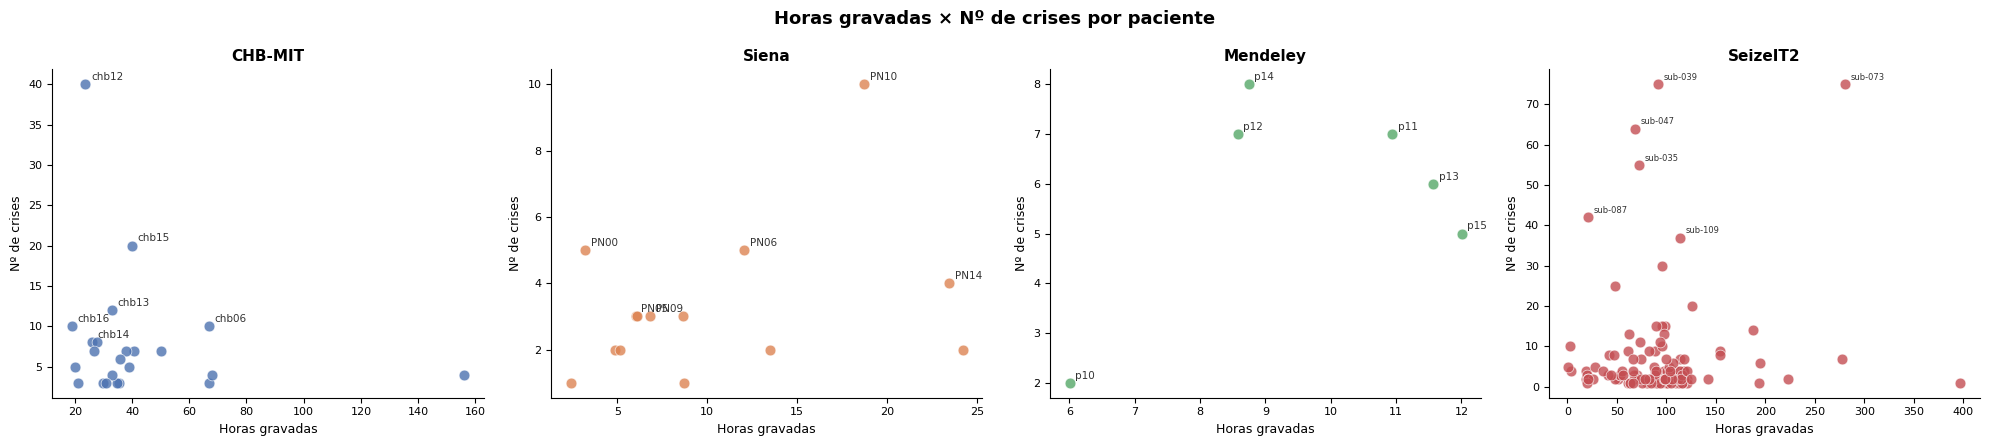

💾 data\inventory\scatter_hours_vs_seizures.png


In [27]:
fig, axes = plt.subplots(1, len(pp), figsize=(5 * len(pp), 4.5))
fig.suptitle('Horas gravadas × Nº de crises por paciente',
             fontsize=13, fontweight='bold')

for ax, (ds_name, df_pp) in zip(axes, pp.items()):
    color = COLORS[ds_name]
    ax.scatter(df_pp['total_rec_h'], df_pp['total_seizures'],
               c=color, s=60, alpha=0.8, edgecolors='white', linewidths=0.5)

    # Anota os Top 6 (mais crises)
    top6 = df_pp.nlargest(TOP_N, 'total_seizures')
    for _, row in top6.iterrows():
        ax.annotate(row['patient'],
                    xy=(row['total_rec_h'], row['total_seizures']),
                    xytext=(4, 3), textcoords='offset points',
                    fontsize=6 if len(df_pp) > 30 else 7.5,
                    color='#333333')

    ax.set_title(ds_name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Horas gravadas', fontsize=9)
    ax.set_ylabel('Nº de crises', fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(labelsize=8)

plt.tight_layout()
out = os.path.join(OUT_DIR, 'scatter_hours_vs_seizures.png')
plt.savefig(out, dpi=140, bbox_inches='tight')
plt.show()
print(f'💾 {out}')


---
> **Nota sobre as classes (janela padrão = 5 min = 300 s):**
> - **Ictal** — durante a crise (onset → offset conforme anotação)
> - **Pré-ictal** — até 5 min *antes* de cada crise
> - **Pós-ictal** — até 5 min *depois* de cada crise
> - **Inter-ictal** — restante (longe de qualquer crise)
>
> Para alterar a janela, mude `window_s=300` em `classify_recording()`.

---
✅ **Fim do Notebook 0.**

Arquivos em `data/inventory/`:
`inventory_*.csv` · `per_patient_*.csv` · `inventory_summary.csv`
`top6_all_datasets.png` · `top6_*.png` · `classes_top6.png` · `scatter_hours_vs_seizures.png`

Prossiga para o **Notebook 1 — Download & Pré-processamento**.
